In [1]:
## Imports

import iris
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import iris.plot as iplt
import iris.quickplot as qplt
import iris.analysis.cartography
import iris.analysis
import aeolus
import aeolus.calc
import aeolus.coord
import matplotlib.colors as mcolors
import matplotlib.ticker


import warnings
warnings.filterwarnings("ignore")


In [2]:
## Load the model output for the original Aglyamov et al. (2021) model when ran over the five surface pressures
agly_sim_0p25bar = iris.load('/home/jj22956/exo_lightning_msci_project/src_original/data/plume_model_output/plume_model_output_default.nc')
agly_sim_0p5bar = iris.load('/home/jj22956/exo_lightning_msci_project/src_original/data/plume_model_output/plume_model_output_run01.nc')
agly_sim_1bar = iris.load('/home/jj22956/exo_lightning_msci_project/src_original/data/plume_model_output/plume_model_output_run02.nc')
agly_sim_2bar = iris.load('/home/jj22956/exo_lightning_msci_project/src_original/data/plume_model_output/plume_model_output_run03.nc')
agly_sim_4bar = iris.load('/home/jj22956/exo_lightning_msci_project/src_original/data/plume_model_output/plume_model_output_run04.nc')

In [3]:
## Load the model output for my updated model using the new temp_strat function when ran over the five surface pressures

new_sim_0p25bar = iris.load('/home/jj22956/exo_lightning_msci_project/src_odhuba/data/plume_model_output/plume_model_output_default.nc')
new_sim_0p5bar = iris.load('/home/jj22956/exo_lightning_msci_project/src_odhuba/data/plume_model_output/plume_model_output_run01.nc')
new_sim_1bar = iris.load('/home/jj22956/exo_lightning_msci_project/src_odhuba/data/plume_model_output/plume_model_output_run02.nc')
new_sim_2bar = iris.load('/home/jj22956/exo_lightning_msci_project/src_odhuba/data/plume_model_output/plume_model_output_run03.nc')
new_sim_4bar = iris.load('/home/jj22956/exo_lightning_msci_project/src_odhuba/data/plume_model_output/plume_model_output_run04.nc')


In [4]:
## Load the model output for the sigma-scaled ISA version of the Aglyamov et al. (2021) model when ran over the five surface pressures
scaled_sim_0p25bar = iris.load('/home/jj22956/exo_lightning_msci_project/src_scaled_ISA/data/plume_model_output/plume_model_output_default.nc')
scaled_sim_0p5bar = iris.load('/home/jj22956/exo_lightning_msci_project/src_scaled_ISA/data/plume_model_output/plume_model_output_run01.nc')
scaled_sim_1bar = iris.load('/home/jj22956/exo_lightning_msci_project/src_scaled_ISA/data/plume_model_output/plume_model_output_run02.nc')
scaled_sim_2bar = iris.load('/home/jj22956/exo_lightning_msci_project/src_scaled_ISA/data/plume_model_output/plume_model_output_run03.nc')
scaled_sim_4bar = iris.load('/home/jj22956/exo_lightning_msci_project/src_scaled_ISA/data/plume_model_output/plume_model_output_run04.nc')

In [5]:
# new_sim_0p25bar

In [ ]:
## Functions for loading te six different plume characterostic cubes from the simulation output

def plume_velocity(cube):
    return cube.extract_cube('velocity')
    
def plume_temp(cube):
    return cube.extract_cube('plume_temp')

def env_temp(cube):
    return cube.extract_cube('env_temp')

def plume_env_temp(cube):
    return cube.extract_cube('plume_temp') - cube.extract_cube('env_temp')

def plume_radius(cube):
    return cube.extract_cube('plume_radius')

def LFR(cube):
    return cube.extract_cube('flash_rate')


In [ ]:
filelist = [
    agly_sim_0p25bar, agly_sim_0p5bar, agly_sim_1bar, agly_sim_2bar, agly_sim_4bar, 
    new_sim_0p25bar, new_sim_0p5bar, new_sim_1bar, new_sim_2bar, new_sim_4bar,
    scaled_sim_0p25bar, scaled_sim_0p5bar, scaled_sim_1bar, scaled_sim_2bar, scaled_sim_4bar
    ]

## Creating arrays of the different surface pressures containing each simulation type

p25 = [agly_sim_0p25bar, new_sim_0p25bar, scaled_sim_0p25bar]
p5 = [agly_sim_0p5bar, new_sim_0p5bar, scaled_sim_0p5bar]
one = [agly_sim_1bar, new_sim_1bar, scaled_sim_1bar]
two = [agly_sim_2bar, new_sim_2bar, scaled_sim_2bar]
four = [agly_sim_4bar, new_sim_4bar, scaled_sim_4bar]


In [8]:
p25_surfacepressure = 0.25e5
p5_surfacepressure = 0.5e5
one_surfacepressure = 1e5
two_surfacepressure = 2e5
four_surfacepressure = 4e5

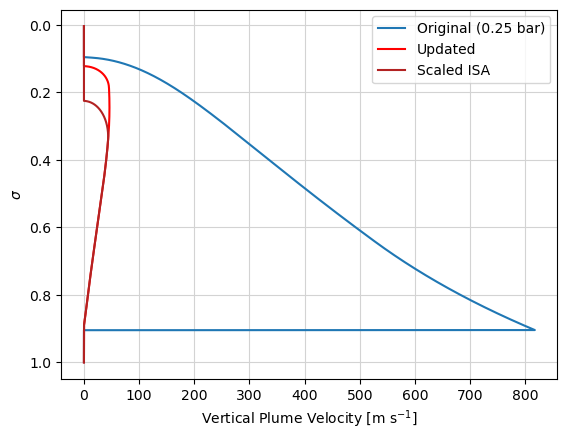

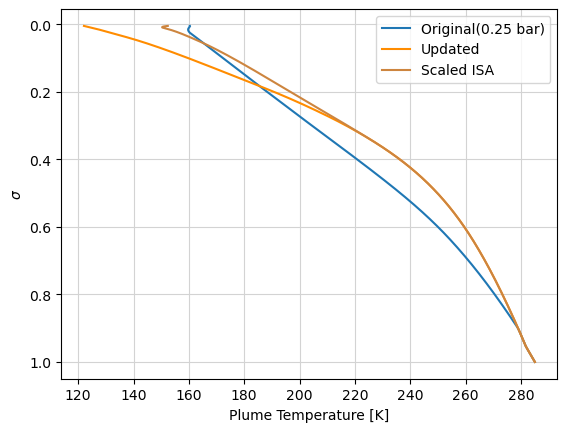

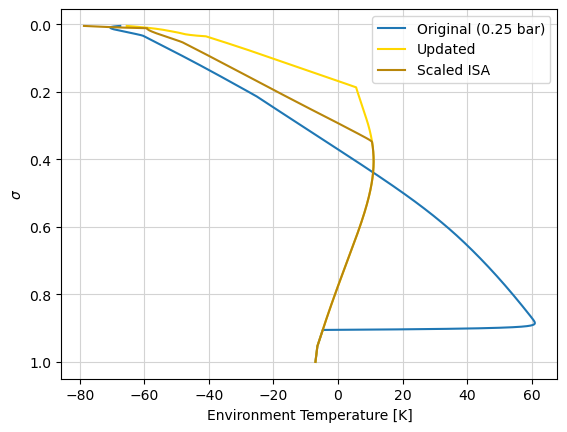

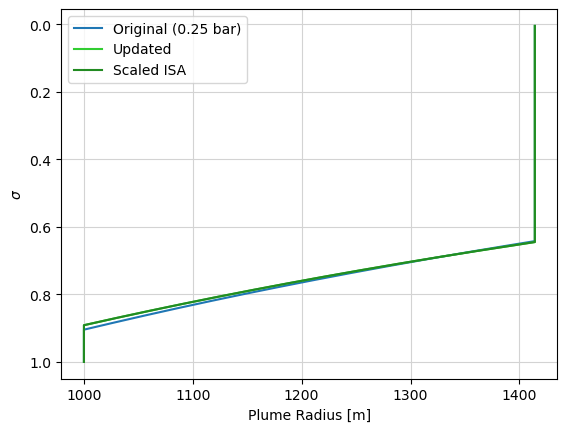

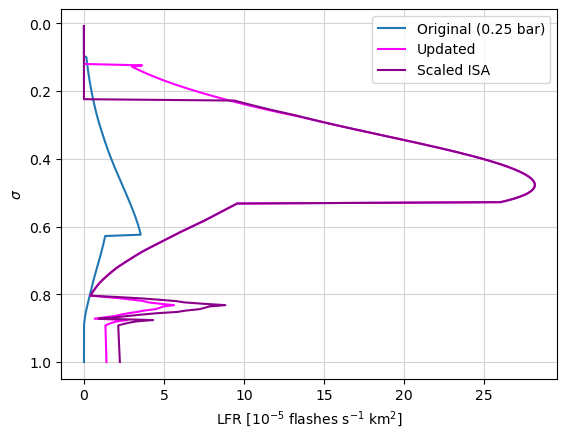

In [ ]:
## Loading and plotting all the 0.25 bar surface pressure data output from the three simulations

for i in p25:
    agly = p25[0]
    new = p25[1]
    scaled = p25[2]

    p25agly_velocity = plume_velocity(agly)
    p25agly_v_p = p25agly_velocity.coord("air_pressure").points / p25_surfacepressure
    p25new_velocity = plume_velocity(new)
    p25new_v_p = p25new_velocity.coord("air_pressure").points / p25_surfacepressure
    p25scaled_velocity = plume_velocity(scaled)
    p25scaled_v_p = p25scaled_velocity.coord("air_pressure").points / p25_surfacepressure

    p25agly_plume_temp = plume_temp(agly)
    p25agly_pt_p = p25agly_plume_temp.coord("air_pressure").points / p25_surfacepressure
    p25new_plume_temp = plume_temp(new)
    p25new_pt_p = p25new_plume_temp.coord("air_pressure").points / p25_surfacepressure
    p25scaled_plume_temp = plume_temp(scaled)
    p25scaled_pt_p = p25scaled_plume_temp.coord("air_pressure").points / p25_surfacepressure

    p25agly_env_temp = plume_env_temp(agly)
    p25agly_et_p = p25agly_env_temp.coord("air_pressure").points / p25_surfacepressure
    p25new_env_temp = plume_env_temp(new)
    p25new_et_p = p25new_env_temp.coord("air_pressure").points / p25_surfacepressure
    p25scaled_env_temp = plume_env_temp(scaled)
    p25scaled_et_p = p25scaled_env_temp.coord("air_pressure").points / p25_surfacepressure

    p25agly_radius = plume_radius(agly)
    p25agly_r_p = p25agly_radius.coord("air_pressure").points / p25_surfacepressure
    p25new_radius = plume_radius(new)
    p25new_r_p = p25new_radius.coord("air_pressure").points / p25_surfacepressure
    p25scaled_radius = plume_radius(scaled)
    p25scaled_r_p = p25scaled_radius.coord("air_pressure").points / p25_surfacepressure

    p25agly_LFR = LFR(agly)
    p25agly_LFR_p = p25agly_LFR.coord("air_pressure").points / p25_surfacepressure
    p25new_LFR = LFR(new)
    p25new_LFR_p = p25new_LFR.coord("air_pressure").points / p25_surfacepressure
    p25scaled_LFR = LFR(scaled)
    p25scaled_LFR_p = p25scaled_LFR.coord("air_pressure").points / p25_surfacepressure


plt.plot(p25agly_velocity.data, p25agly_v_p, label='Original (0.25 bar)')
plt.plot(p25new_velocity.data, p25new_v_p, color='red', label='Updated')
plt.plot(p25scaled_velocity.data, p25scaled_v_p, color='firebrick', label='Scaled ISA')
plt.gca().invert_yaxis()
plt.grid(color='lightgrey')
plt.xlabel(r'Vertical Plume Velocity [m s$^{-1}$]')
plt.ylabel(r'$\sigma$')
plt.legend()
plt.savefig('/data/cluster4/jj22956/model_comparison_figures/p25/plume_velocity.pdf')
plt.show()

plt.plot(p25agly_plume_temp.data, p25agly_pt_p, label='Original(0.25 bar)')
plt.plot(p25new_plume_temp.data, p25new_pt_p, color='darkorange', label='Updated')
plt.plot(p25scaled_plume_temp.data, p25scaled_pt_p, color='peru', label='Scaled ISA')
plt.gca().invert_yaxis()
plt.grid(color='lightgrey')
plt.xlabel('Plume Temperature [K]')
plt.ylabel(r'$\sigma$')
plt.legend()
plt.savefig('/data/cluster4/jj22956/model_comparison_figures/p25/plume_temperature.pdf')
plt.show()

plt.plot(p25agly_env_temp.data, p25agly_et_p, label='Original (0.25 bar)')
plt.plot(p25new_env_temp.data, p25new_et_p, color='gold', label='Updated')
plt.plot(p25scaled_env_temp.data, p25scaled_et_p, color='darkgoldenrod', label='Scaled ISA')
plt.gca().invert_yaxis()
plt.grid(color='lightgrey')
plt.xlabel('Environment Temperature [K]')
plt.ylabel(r'$\sigma$')
plt.legend()
plt.savefig('/data/cluster4/jj22956/model_comparison_figures/p25/environment_temperature.pdf')
plt.show()

# plt.plot(p25agly_env_temp.data, p25agly_et_p, label='Original (0.25 bar)')
# plt.plot(p25new_env_temp.data, p25new_et_p, color='gold', label='Updated')
# plt.plot(p25scaled_env_temp.data, p25scaled_et_p, color='darkgoldenrod', label='Scaled ISA')
# plt.gca().invert_yaxis()
# plt.grid(color='lightgrey')
# plt.xlabel('Environment Temperature [K]')
# plt.ylabel(r'$\sigma$')
# plt.legend()
# plt.savefig('/data/cluster4/jj22956/model_comparison_figures/p25/environment_temperature.pdf')
# plt.show()

plt.plot(p25agly_radius.data, p25agly_r_p, label='Original (0.25 bar)')
plt.plot(p25new_radius.data, p25new_r_p, color='limegreen', label='Updated')
plt.plot(p25scaled_radius.data, p25scaled_r_p, color='forestgreen', label='Scaled ISA')
plt.gca().invert_yaxis()
plt.grid(color='lightgrey')
plt.xlabel('Plume Radius [m]')
plt.ylabel(r'$\sigma$')
plt.legend()
plt.savefig('/data/cluster4/jj22956/model_comparison_figures/p25/plume_radius.pdf')
plt.show()

plt.plot(p25agly_LFR.data*1e5, p25agly_LFR_p, label='Original (0.25 bar)')
plt.plot(p25new_LFR.data*1e5, p25new_LFR_p, color='magenta', label='Updated')
plt.plot(p25scaled_LFR.data*1e5, p25scaled_LFR_p, color='darkmagenta', label='Scaled ISA')
plt.gca().invert_yaxis()
plt.grid(color='lightgrey')
plt.xlabel(r'LFR [10$^{-5}$ flashes s$^{-1}$ km$^{2}$]')
plt.ylabel(r'$\sigma$')
plt.legend()
plt.savefig('/data/cluster4/jj22956/model_comparison_figures/p25/LFR.pdf')
plt.show()

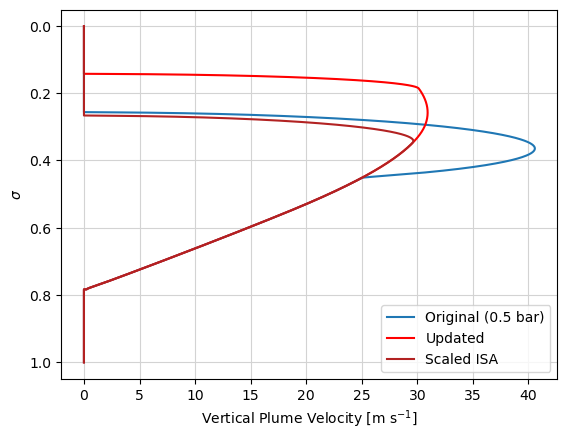

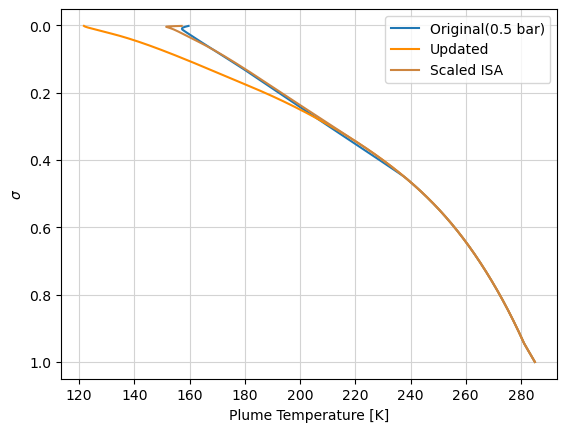

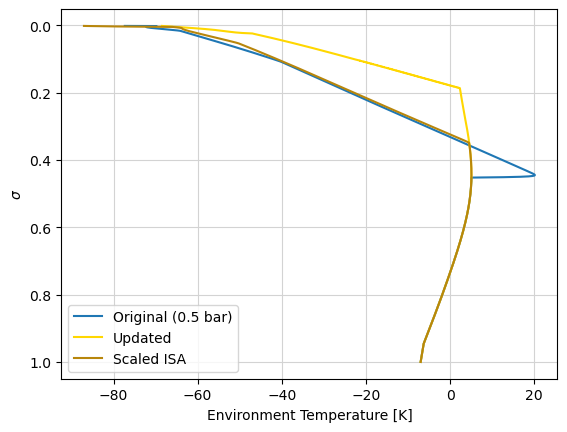

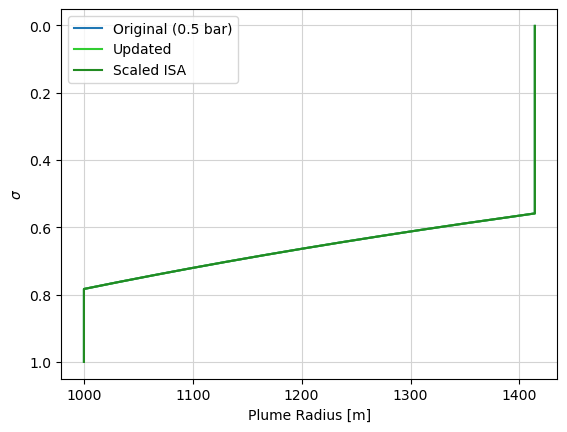

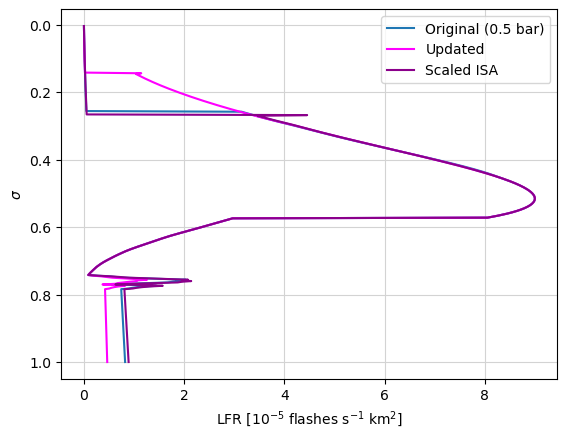

In [ ]:
## Loading and plotting all the 0.5 bar surface pressure data output from the three simulations

for i in p5:
    agly = p5[0]
    new = p5[1]
    scaled = p5[2]

    p5agly_velocity = plume_velocity(agly)
    p5agly_v_p = p5agly_velocity.coord("air_pressure").points / p5_surfacepressure
    p5new_velocity = plume_velocity(new)
    p5new_v_p = p5new_velocity.coord("air_pressure").points / p5_surfacepressure
    p5scaled_velocity = plume_velocity(scaled)
    p5scaled_v_p = p5scaled_velocity.coord("air_pressure").points / p5_surfacepressure
    
    p5agly_plume_temp = plume_temp(agly)
    p5agly_pt_p = p5agly_plume_temp.coord("air_pressure").points / p5_surfacepressure
    p5new_plume_temp = plume_temp(new)
    p5new_pt_p = p5new_plume_temp.coord("air_pressure").points / p5_surfacepressure
    p5scaled_plume_temp = plume_temp(scaled)
    p5scaled_pt_p = p5scaled_plume_temp.coord("air_pressure").points / p5_surfacepressure


    p5agly_env_temp = plume_env_temp(agly)
    p5agly_et_p = p5agly_env_temp.coord("air_pressure").points / p5_surfacepressure
    p5new_env_temp = plume_env_temp(new)
    p5new_et_p = p5new_env_temp.coord("air_pressure").points / p5_surfacepressure
    p5scaled_env_temp = plume_env_temp(scaled)
    p5scaled_et_p = p5scaled_env_temp.coord("air_pressure").points / p5_surfacepressure

    p5agly_radius = plume_radius(agly)
    p5agly_r_p = p5agly_radius.coord("air_pressure").points / p5_surfacepressure
    p5new_radius = plume_radius(new)
    p5new_r_p = p5new_radius.coord("air_pressure").points / p5_surfacepressure
    p5scaled_radius = plume_radius(scaled)
    p5scaled_r_p = p5scaled_radius.coord("air_pressure").points / p5_surfacepressure

    p5agly_LFR = LFR(agly)
    p5agly_LFR_p = p5agly_LFR.coord("air_pressure").points / p5_surfacepressure
    p5new_LFR = LFR(new)
    p5new_LFR_p = p5new_LFR.coord("air_pressure").points / p5_surfacepressure
    p5scaled_LFR = LFR(scaled)
    p5scaled_LFR_p = p5scaled_LFR.coord("air_pressure").points / p5_surfacepressure


plt.plot(p5agly_velocity.data, p5agly_v_p, label='Original (0.5 bar)')
plt.plot(p5new_velocity.data, p5new_v_p, color='red', label='Updated')
plt.plot(p5scaled_velocity.data, p5scaled_v_p, color='firebrick', label='Scaled ISA')
plt.gca().invert_yaxis()
plt.grid(color='lightgrey')
plt.xlabel(r'Vertical Plume Velocity [m s$^{-1}$]')
plt.ylabel(r'$\sigma$')
plt.legend()
plt.savefig('/data/cluster4/jj22956/model_comparison_figures/p5/plume_velocity.pdf')
plt.show()

plt.plot(p5agly_plume_temp.data, p5agly_pt_p, label='Original(0.5 bar)')
plt.plot(p5new_plume_temp.data, p5new_pt_p, color='darkorange', label='Updated')
plt.plot(p5scaled_plume_temp.data, p5scaled_pt_p, color='peru', label='Scaled ISA')
plt.gca().invert_yaxis()
plt.grid(color='lightgrey')
plt.xlabel('Plume Temperature [K]')
plt.ylabel(r'$\sigma$')
plt.legend()
plt.savefig('/data/cluster4/jj22956/model_comparison_figures/p5/plume_temperature.pdf')
plt.show()

plt.plot(p5agly_env_temp.data, p5agly_et_p, label='Original (0.5 bar)')
plt.plot(p5new_env_temp.data, p5new_et_p, color='gold', label='Updated')
plt.plot(p5scaled_env_temp.data, p5scaled_et_p, color='darkgoldenrod', label='Scaled ISA')
plt.gca().invert_yaxis()
plt.grid(color='lightgrey')
plt.xlabel('Environment Temperature [K]')
plt.ylabel(r'$\sigma$')
plt.legend()
plt.savefig('/data/cluster4/jj22956/model_comparison_figures/p5/environment_temperature.pdf')
plt.show()

plt.plot(p5agly_radius.data, p5agly_r_p, label='Original (0.5 bar)')
plt.plot(p5new_radius.data, p5new_r_p, color='limegreen', label='Updated')
plt.plot(p5scaled_radius.data, p5scaled_r_p, color='forestgreen', label='Scaled ISA')
plt.gca().invert_yaxis()
plt.grid(color='lightgrey')
plt.xlabel('Plume Radius [m]')
plt.ylabel(r'$\sigma$')
plt.legend()
plt.savefig('/data/cluster4/jj22956/model_comparison_figures/p5/plume_radius.pdf')
plt.show()

plt.plot(p5agly_LFR.data*1e5, p5agly_LFR_p, label='Original (0.5 bar)')
plt.plot(p5new_LFR.data*1e5, p5new_LFR_p, color='magenta', label='Updated')
plt.plot(p5scaled_LFR.data*1e5, p5scaled_LFR_p, color='darkmagenta', label='Scaled ISA')
plt.gca().invert_yaxis()
plt.grid(color='lightgrey')
plt.xlabel(r'LFR [10$^{-5}$ flashes s$^{-1}$ km$^{2}$]')
plt.ylabel(r'$\sigma$')
plt.legend()
plt.savefig('/data/cluster4/jj22956/model_comparison_figures/p5/LFR.pdf')
plt.show()

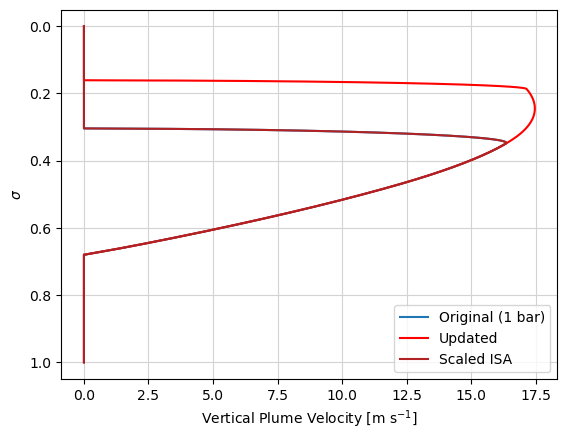

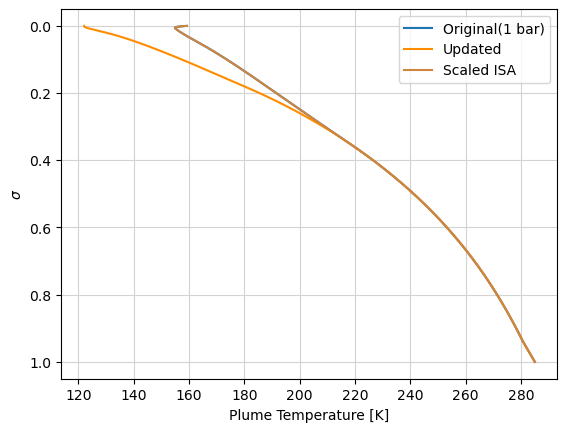

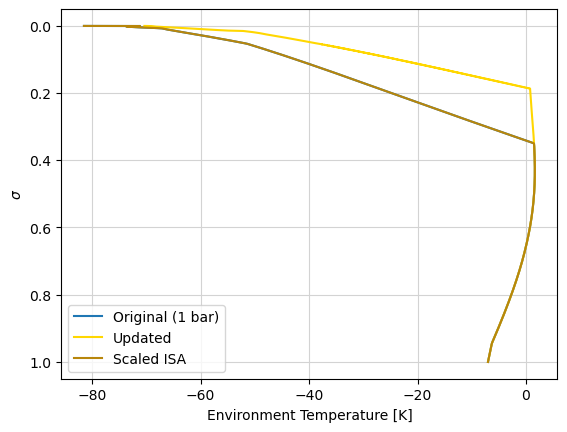

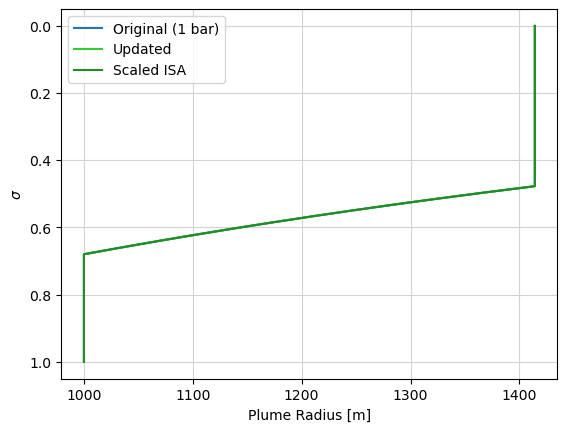

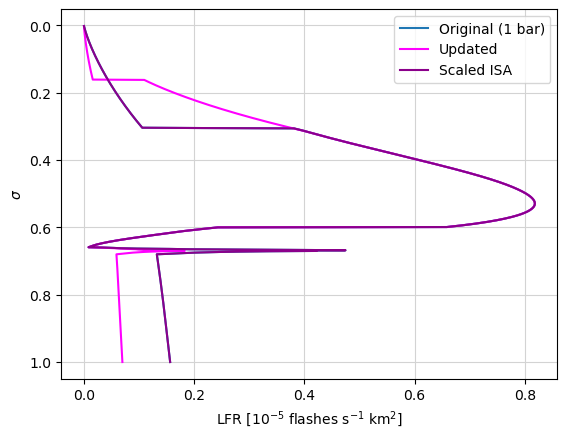

In [ ]:
## Loading and plotting all the 1 bar surface pressure data output from the three simulations

for i in one:
    agly = one[0]
    new = one[1]
    scaled = one[2]

    oneagly_velocity = plume_velocity(agly)
    oneagly_v_p = oneagly_velocity.coord("air_pressure").points / one_surfacepressure
    onenew_velocity = plume_velocity(new)
    onenew_v_p = onenew_velocity.coord("air_pressure").points / one_surfacepressure
    onescaled_velocity = plume_velocity(scaled)
    onescaled_v_p = onescaled_velocity.coord("air_pressure").points / one_surfacepressure

    oneagly_plume_temp = plume_temp(agly)
    oneagly_pt_p = oneagly_plume_temp.coord("air_pressure").points / one_surfacepressure
    onenew_plume_temp = plume_temp(new)
    onenew_pt_p = onenew_plume_temp.coord("air_pressure").points / one_surfacepressure
    onescaled_plume_temp = plume_temp(scaled)
    onescaled_pt_p = onescaled_plume_temp.coord("air_pressure").points / one_surfacepressure

    oneagly_env_temp = plume_env_temp(agly)
    oneagly_et_p = oneagly_env_temp.coord("air_pressure").points / one_surfacepressure
    onenew_env_temp = plume_env_temp(new)
    onenew_et_p = onenew_env_temp.coord("air_pressure").points / one_surfacepressure
    onescaled_env_temp = plume_env_temp(scaled)
    onescaled_et_p = onescaled_env_temp.coord("air_pressure").points / one_surfacepressure

    oneagly_radius = plume_radius(agly)
    oneagly_r_p = oneagly_radius.coord("air_pressure").points / one_surfacepressure
    onenew_radius = plume_radius(new)
    onenew_r_p = onenew_radius.coord("air_pressure").points / one_surfacepressure
    onescaled_radius = plume_radius(scaled)
    onescaled_r_p = onescaled_radius.coord("air_pressure").points / one_surfacepressure

    oneagly_LFR = LFR(agly)
    oneagly_LFR_p = oneagly_LFR.coord("air_pressure").points / one_surfacepressure
    onenew_LFR = LFR(new)
    onenew_LFR_p = onenew_LFR.coord("air_pressure").points / one_surfacepressure
    onescaled_LFR = LFR(scaled)
    onescaled_LFR_p = onescaled_LFR.coord("air_pressure").points / one_surfacepressure


plt.plot(oneagly_velocity.data, oneagly_v_p, label='Original (1 bar)')
plt.plot(onenew_velocity.data, onenew_v_p, color='red', label='Updated')
plt.plot(onescaled_velocity.data, onescaled_v_p, color='firebrick', label='Scaled ISA')
plt.gca().invert_yaxis()
plt.grid(color='lightgrey')
plt.xlabel(r'Vertical Plume Velocity [m s$^{-1}$]')
plt.ylabel(r'$\sigma$')
plt.legend()
plt.savefig('/data/cluster4/jj22956/model_comparison_figures/one/plume_velocity.pdf')
plt.show()

plt.plot(oneagly_plume_temp.data, oneagly_pt_p, label='Original(1 bar)')
plt.plot(onenew_plume_temp.data, onenew_pt_p, color='darkorange', label='Updated')
plt.plot(onescaled_plume_temp.data, onescaled_pt_p, color='peru', label='Scaled ISA')
plt.gca().invert_yaxis()
plt.grid(color='lightgrey')
plt.xlabel('Plume Temperature [K]')
plt.ylabel(r'$\sigma$')
plt.legend()
plt.savefig('/data/cluster4/jj22956/model_comparison_figures/one/plume_temperature.pdf')
plt.show()

plt.plot(oneagly_env_temp.data, oneagly_et_p, label='Original (1 bar)')
plt.plot(onenew_env_temp.data, onenew_et_p, color='gold', label='Updated')
plt.plot(onescaled_env_temp.data, onescaled_et_p, color='darkgoldenrod', label='Scaled ISA')
plt.gca().invert_yaxis()
plt.grid(color='lightgrey')
plt.xlabel('Environment Temperature [K]')
plt.ylabel(r'$\sigma$')
plt.legend()
plt.savefig('/data/cluster4/jj22956/model_comparison_figures/one/environment_temperature.pdf')
plt.show()

plt.plot(oneagly_radius.data, oneagly_r_p, label='Original (1 bar)')
plt.plot(onenew_radius.data, onenew_r_p, color='limegreen', label='Updated')
plt.plot(onescaled_radius.data, onescaled_r_p, color='forestgreen', label='Scaled ISA')
plt.gca().invert_yaxis()
plt.grid(color='lightgrey')
plt.xlabel('Plume Radius [m]')
plt.ylabel(r'$\sigma$')
plt.legend()
plt.savefig('/data/cluster4/jj22956/model_comparison_figures/one/plume_radius.pdf')
plt.show()

plt.plot(oneagly_LFR.data*1e5, oneagly_LFR_p, label='Original (1 bar)')
plt.plot(onenew_LFR.data*1e5, onenew_LFR_p, color='magenta', label='Updated')
plt.plot(onescaled_LFR.data*1e5, onescaled_LFR_p, color='darkmagenta', label='Scaled ISA')
plt.gca().invert_yaxis()
plt.grid(color='lightgrey')
plt.xlabel(r'LFR [10$^{-5}$ flashes s$^{-1}$ km$^{2}$]')
plt.ylabel(r'$\sigma$')
plt.legend()
plt.savefig('/data/cluster4/jj22956/model_comparison_figures/one/LFR.pdf')
plt.show()

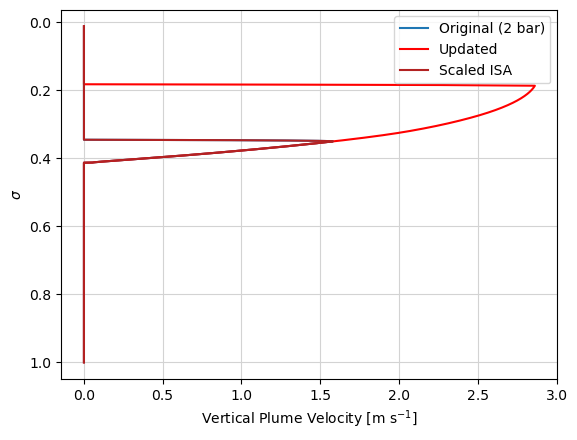

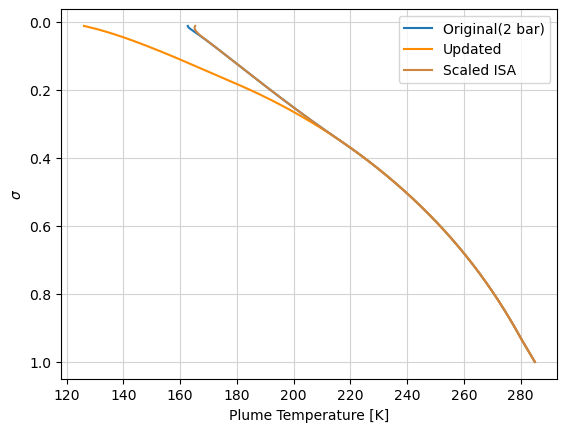

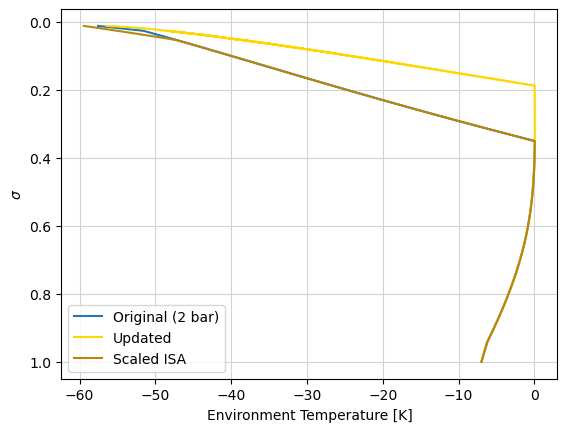

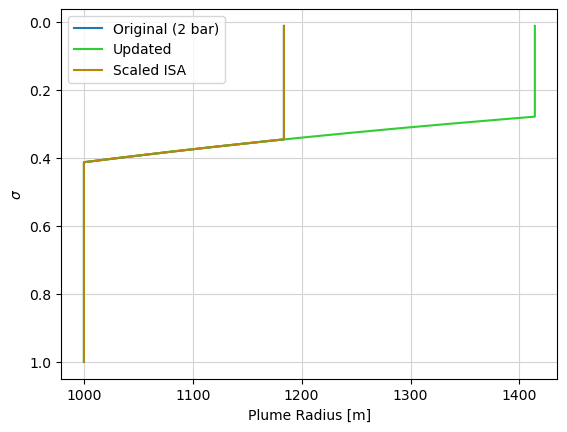

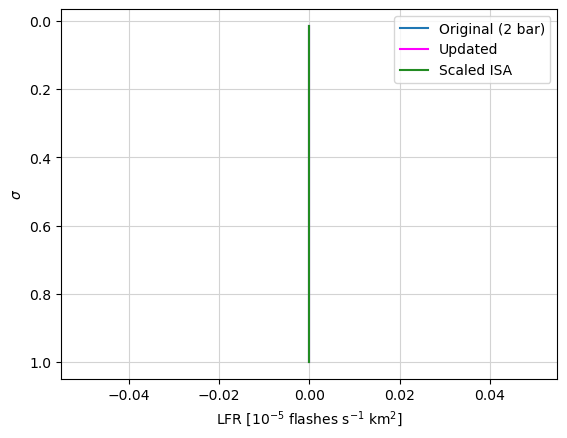

In [ ]:
## Loading and plotting all the 2 bar surface pressure data output from the three simulations

for i in two:
    agly = two[0]
    new = two[1]
    scaled = two[2]

    twoagly_velocity = plume_velocity(agly)
    twoagly_v_p = twoagly_velocity.coord("air_pressure").points / two_surfacepressure
    twonew_velocity = plume_velocity(new)
    twonew_v_p = twonew_velocity.coord("air_pressure").points / two_surfacepressure
    twoscaled_velocity = plume_velocity(scaled)
    twoscaled_v_p = twoscaled_velocity.coord("air_pressure").points / two_surfacepressure

    twoagly_plume_temp = plume_temp(agly)
    twoagly_pt_p = twoagly_plume_temp.coord("air_pressure").points / two_surfacepressure
    twonew_plume_temp = plume_temp(new)
    twonew_pt_p = twonew_plume_temp.coord("air_pressure").points / two_surfacepressure
    twoscaled_plume_temp = plume_temp(scaled)
    twoscaled_pt_p = twoscaled_plume_temp.coord("air_pressure").points / two_surfacepressure


    twoagly_env_temp = plume_env_temp(agly)
    twoagly_et_p = twoagly_env_temp.coord("air_pressure").points / two_surfacepressure
    twonew_env_temp = plume_env_temp(new)
    twonew_et_p = twonew_env_temp.coord("air_pressure").points / two_surfacepressure
    twoscaled_env_temp = plume_env_temp(scaled)
    twoscaled_et_p = twoscaled_env_temp.coord("air_pressure").points / two_surfacepressure

    twoagly_radius = plume_radius(agly)
    twoagly_r_p = twoagly_radius.coord("air_pressure").points / two_surfacepressure
    twonew_radius = plume_radius(new)
    twonew_r_p = twonew_radius.coord("air_pressure").points / two_surfacepressure
    twoscaled_radius = plume_radius(scaled)
    twoscaled_r_p = twoscaled_radius.coord("air_pressure").points / two_surfacepressure

    twoagly_LFR = LFR(agly)
    twoagly_LFR_p = twoagly_LFR.coord("air_pressure").points / two_surfacepressure
    twonew_LFR = LFR(new)
    twonew_LFR_p = twonew_LFR.coord("air_pressure").points / two_surfacepressure
    twoscaled_LFR = LFR(scaled)
    twoscaled_LFR_p = twoscaled_LFR.coord("air_pressure").points / two_surfacepressure


plt.plot(twoagly_velocity.data, twoagly_v_p, label='Original (2 bar)')
plt.plot(twonew_velocity.data, twonew_v_p, color='red', label='Updated')
plt.plot(twoscaled_velocity.data, twoscaled_v_p, color='firebrick', label='Scaled ISA')
plt.gca().invert_yaxis()
plt.grid(color='lightgrey')
plt.xlabel(r'Vertical Plume Velocity [m s$^{-1}$]')
plt.ylabel(r'$\sigma$')
plt.legend()
plt.savefig('/data/cluster4/jj22956/model_comparison_figures/two/plume_velocity.pdf')
plt.show()

plt.plot(twoagly_plume_temp.data, twoagly_pt_p, label='Original(2 bar)')
plt.plot(twonew_plume_temp.data, twonew_pt_p, color='darkorange', label='Updated')
plt.plot(twoscaled_plume_temp.data, twoscaled_pt_p, color='peru', label='Scaled ISA')
plt.gca().invert_yaxis()
plt.grid(color='lightgrey')
plt.xlabel('Plume Temperature [K]')
plt.ylabel(r'$\sigma$')
plt.legend()
plt.savefig('/data/cluster4/jj22956/model_comparison_figures/two/plume_temperature.pdf')
plt.show()

plt.plot(twoagly_env_temp.data, twoagly_et_p, label='Original (2 bar)')
plt.plot(twonew_env_temp.data, twonew_et_p, color='gold', label='Updated')
plt.plot(twoscaled_env_temp.data, twoscaled_et_p, color='darkgoldenrod', label='Scaled ISA')
plt.gca().invert_yaxis()
plt.grid(color='lightgrey')
plt.xlabel('Environment Temperature [K]')
plt.ylabel(r'$\sigma$')
plt.legend()
plt.savefig('/data/cluster4/jj22956/model_comparison_figures/two/environment_temperature.pdf')
plt.show()

plt.plot(twoagly_radius.data, twoagly_r_p, label='Original (2 bar)')
plt.plot(twonew_radius.data, twonew_r_p, color='limegreen', label='Updated')
plt.plot(twoscaled_radius.data, twoscaled_r_p, color='darkgoldenrod', label='Scaled ISA')
plt.gca().invert_yaxis()
plt.grid(color='lightgrey')
plt.xlabel('Plume Radius [m]')
plt.ylabel(r'$\sigma$')
plt.legend()
plt.savefig('/data/cluster4/jj22956/model_comparison_figures/two/plume_radius.pdf')
plt.show()

plt.plot(twoagly_LFR.data*1e5, twoagly_LFR_p, label='Original (2 bar)')
plt.plot(twonew_LFR.data*1e5, twonew_LFR_p, color='magenta', label='Updated')
plt.plot(twoscaled_LFR.data, twoscaled_LFR_p, color='forestgreen', label='Scaled ISA')
plt.gca().invert_yaxis()
plt.grid(color='lightgrey')
plt.xlabel(r'LFR [10$^{-5}$ flashes s$^{-1}$ km$^{2}$]')
plt.ylabel(r'$\sigma$')
plt.legend()
plt.savefig('/data/cluster4/jj22956/model_comparison_figures/two/LFR.pdf')
plt.show()

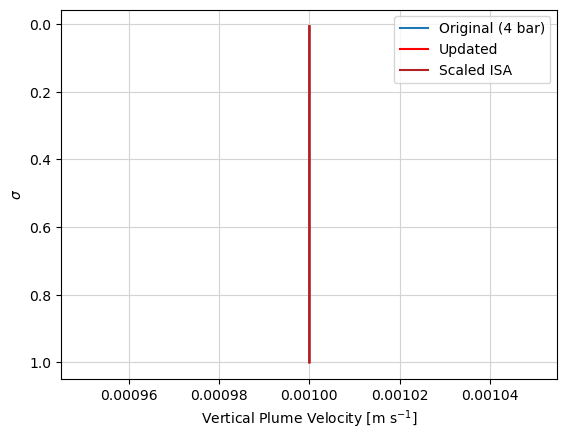

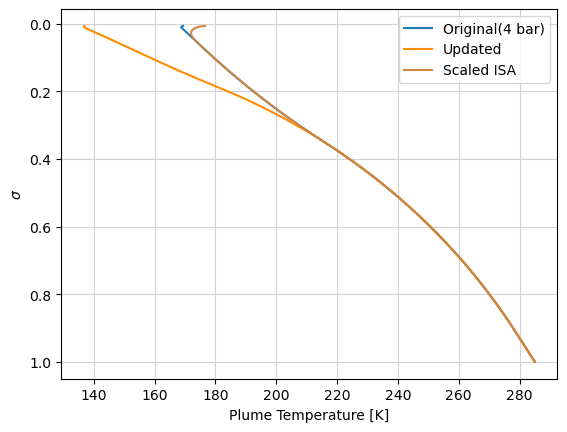

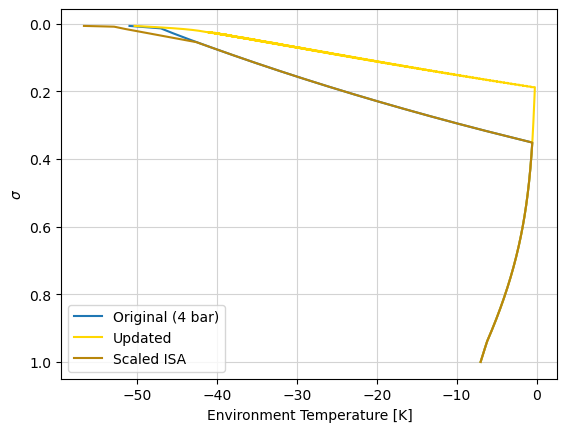

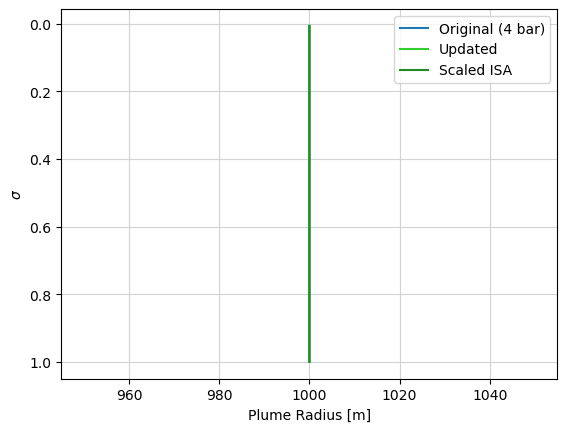

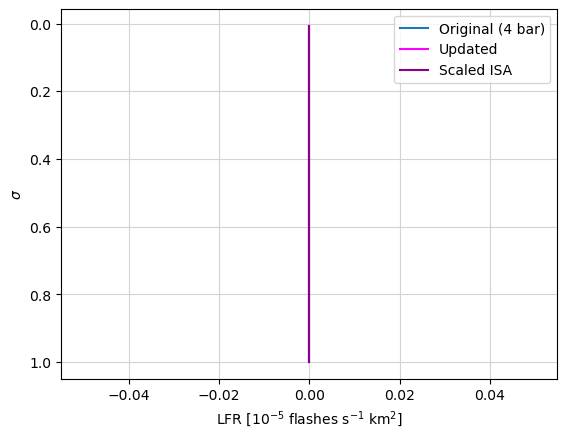

In [ ]:
## Loading and plotting all the 4 bar surface pressure data output from the three simulations

for i in four:
    agly = four[0]
    new = four[1]
    scaled = four[2]

    fouragly_velocity = plume_velocity(agly)
    fouragly_v_p = fouragly_velocity.coord("air_pressure").points / four_surfacepressure
    fournew_velocity = plume_velocity(new)
    fournew_v_p = fournew_velocity.coord("air_pressure").points / four_surfacepressure
    fourscaled_velocity = plume_velocity(scaled)
    fourscaled_v_p = fourscaled_velocity.coord("air_pressure").points / four_surfacepressure

    fouragly_plume_temp = plume_temp(agly)
    fouragly_pt_p = fouragly_plume_temp.coord("air_pressure").points / four_surfacepressure
    fournew_plume_temp = plume_temp(new)
    fournew_pt_p = fournew_plume_temp.coord("air_pressure").points / four_surfacepressure
    fourscaled_plume_temp = plume_temp(scaled)
    fourscaled_pt_p = fourscaled_plume_temp.coord("air_pressure").points / four_surfacepressure

    fouragly_env_temp = plume_env_temp(agly)
    fouragly_et_p = fouragly_env_temp.coord("air_pressure").points / four_surfacepressure
    fournew_env_temp = plume_env_temp(new)
    fournew_et_p = fournew_env_temp.coord("air_pressure").points / four_surfacepressure
    fourscaled_env_temp = plume_env_temp(scaled)
    fourscaled_et_p = fourscaled_env_temp.coord("air_pressure").points / four_surfacepressure

    fouragly_radius = plume_radius(agly)
    fouragly_r_p = fouragly_radius.coord("air_pressure").points / four_surfacepressure
    fournew_radius = plume_radius(new)
    fournew_r_p = fournew_radius.coord("air_pressure").points / four_surfacepressure
    fourscaled_radius = plume_radius(scaled)
    fourscaled_r_p = fourscaled_radius.coord("air_pressure").points / four_surfacepressure

    fouragly_LFR = LFR(agly)
    fouragly_LFR_p = fouragly_LFR.coord("air_pressure").points / four_surfacepressure
    fournew_LFR = LFR(new)
    fournew_LFR_p = fournew_LFR.coord("air_pressure").points / four_surfacepressure
    fourscaled_LFR = LFR(scaled)
    fourscaled_LFR_p = fourscaled_LFR.coord("air_pressure").points / four_surfacepressure


plt.plot(fouragly_velocity.data, fouragly_v_p, label='Original (4 bar)')
plt.plot(fournew_velocity.data, fournew_v_p, color='red', label='Updated')
plt.plot(fourscaled_velocity.data, fourscaled_v_p, color='firebrick', label='Scaled ISA')
plt.gca().invert_yaxis()
plt.grid(color='lightgrey')
plt.xlabel(r'Vertical Plume Velocity [m s$^{-1}$]')
plt.ylabel(r'$\sigma$')
plt.legend()
plt.savefig('/data/cluster4/jj22956/model_comparison_figures/four/plume_velocity.pdf')
plt.show()

plt.plot(fouragly_plume_temp.data, fouragly_pt_p, label='Original(4 bar)')
plt.plot(fournew_plume_temp.data, fournew_pt_p, color='darkorange', label='Updated')
plt.plot(fourscaled_plume_temp.data, fourscaled_pt_p, color='peru', label='Scaled ISA')
plt.gca().invert_yaxis()
plt.grid(color='lightgrey')
plt.xlabel('Plume Temperature [K]')
plt.ylabel(r'$\sigma$')
plt.legend()
plt.savefig('/data/cluster4/jj22956/model_comparison_figures/four/plume_temperature.pdf')
plt.show()

plt.plot(fouragly_env_temp.data, fouragly_et_p, label='Original (4 bar)')
plt.plot(fournew_env_temp.data, fournew_et_p, color='gold', label='Updated')
plt.plot(fourscaled_env_temp.data, fourscaled_et_p, color='darkgoldenrod', label='Scaled ISA')
plt.gca().invert_yaxis()
plt.grid(color='lightgrey')
plt.xlabel('Environment Temperature [K]')
plt.ylabel(r'$\sigma$')
plt.legend()
plt.savefig('/data/cluster4/jj22956/model_comparison_figures/four/environment_temperature.pdf')
plt.show()

plt.plot(fouragly_radius.data, fouragly_r_p, label='Original (4 bar)')
plt.plot(fournew_radius.data, fournew_r_p, color='limegreen', label='Updated')
plt.plot(fourscaled_radius.data, fourscaled_r_p, color='forestgreen', label='Scaled ISA')
plt.gca().invert_yaxis()
plt.grid(color='lightgrey')
plt.xlabel('Plume Radius [m]')
plt.ylabel(r'$\sigma$')
plt.legend()
plt.savefig('/data/cluster4/jj22956/model_comparison_figures/four/plume_radius.pdf')
plt.show()

plt.plot(fouragly_LFR.data*1e5, fouragly_LFR_p, label='Original (4 bar)')
plt.plot(fournew_LFR.data*1e5, fournew_LFR_p, color='magenta', label='Updated')
plt.plot(fourscaled_LFR.data*1e5, fourscaled_LFR_p, color='darkmagenta', label='Scaled ISA')
plt.gca().invert_yaxis()
plt.grid(color='lightgrey')
plt.xlabel(r'LFR [10$^{-5}$ flashes s$^{-1}$ km$^{2}$]')
plt.ylabel(r'$\sigma$')
plt.legend()
plt.savefig('/data/cluster4/jj22956/model_comparison_figures/four/LFR.pdf')
plt.show()

In [ ]:
## Now creating composite plots for a single characteristic
## Sub-plots are created for each surface pressure type
## Within each sub-plot the output from all three simulations is plotted for comparison

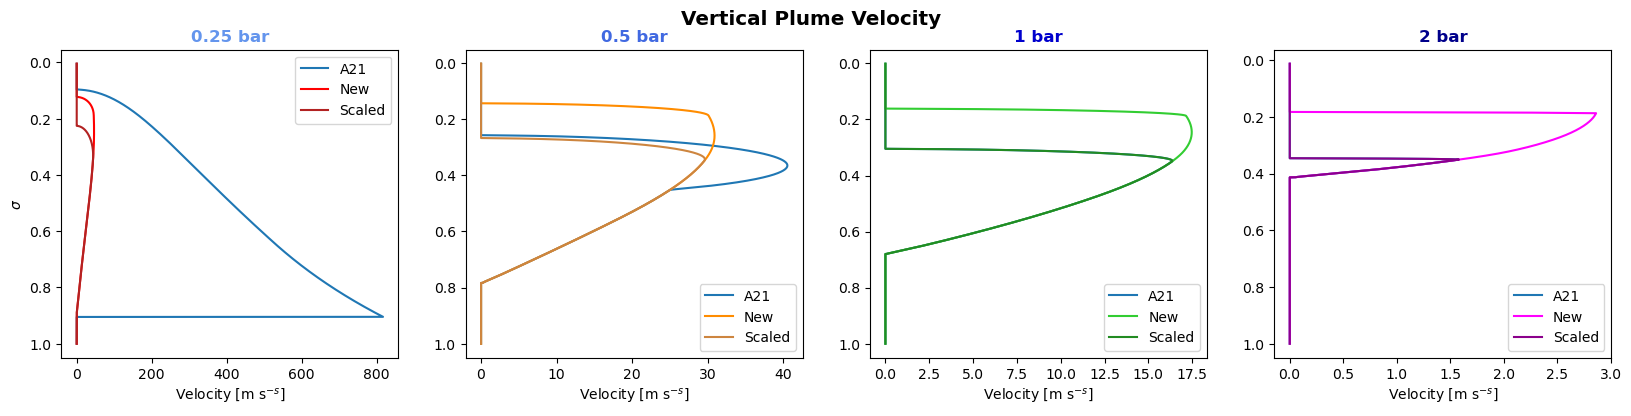

In [ ]:
## Vertical plume velocity

velocity_fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(20, 4))
velocity_fig.suptitle('Vertical Plume Velocity', fontsize='x-large', weight='bold')
ax1.plot(p25agly_velocity.data, p25agly_v_p, label='A21')
ax1.plot(p25new_velocity.data, p25new_v_p, color='red', label='New')
ax1.plot(p25scaled_velocity.data, p25scaled_v_p, color='firebrick', label='Scaled')
ax1.invert_yaxis()
ax1.legend()
ax1.set_xlabel(r'Velocity [m s$^{-s}$]')
ax1.set_ylabel(r'$\sigma$')
ax1.set_title('0.25 bar', color='cornflowerblue', weight='bold')

ax2.plot(p5agly_velocity.data, p5agly_v_p, label='A21')
ax2.plot(p5new_velocity.data, p5new_v_p, color='darkorange', label='New')
ax2.plot(p5scaled_velocity.data, p5scaled_v_p, color='peru', label='Scaled')
ax2.invert_yaxis()
ax2.legend()
ax2.set_xlabel(r'Velocity [m s$^{-s}$]')
ax2.set_title('0.5 bar', color='royalblue', weight='bold')

ax3.plot(oneagly_velocity.data, oneagly_v_p, label='A21')
ax3.plot(onenew_velocity.data, onenew_v_p, color='limegreen', label='New')
ax3.plot(onescaled_velocity.data, onescaled_v_p, color='forestgreen', label='Scaled')
ax3.invert_yaxis()
ax3.legend()
ax3.set_xlabel(r'Velocity [m s$^{-s}$]')
ax3.set_title('1 bar', color='mediumblue', weight='bold')

ax4.plot(twoagly_velocity.data, twoagly_v_p, label='A21')
ax4.plot(twonew_velocity.data, twonew_v_p, color='magenta', label='New')
ax4.plot(twoscaled_velocity.data, twoscaled_v_p, color='darkmagenta', label='Scaled')
ax4.invert_yaxis()
ax4.legend()
ax4.set_xlabel(r'Velocity [m s$^{-s}$]')
ax4.set_title('2 bar', color='darkblue', weight='bold')

velocity_fig.savefig('/data/cluster4/jj22956/model_comparison_figures/combo plots/vertical_plume_velocity.pdf',
    bbox_inches="tight",
    pad_inches=0
)


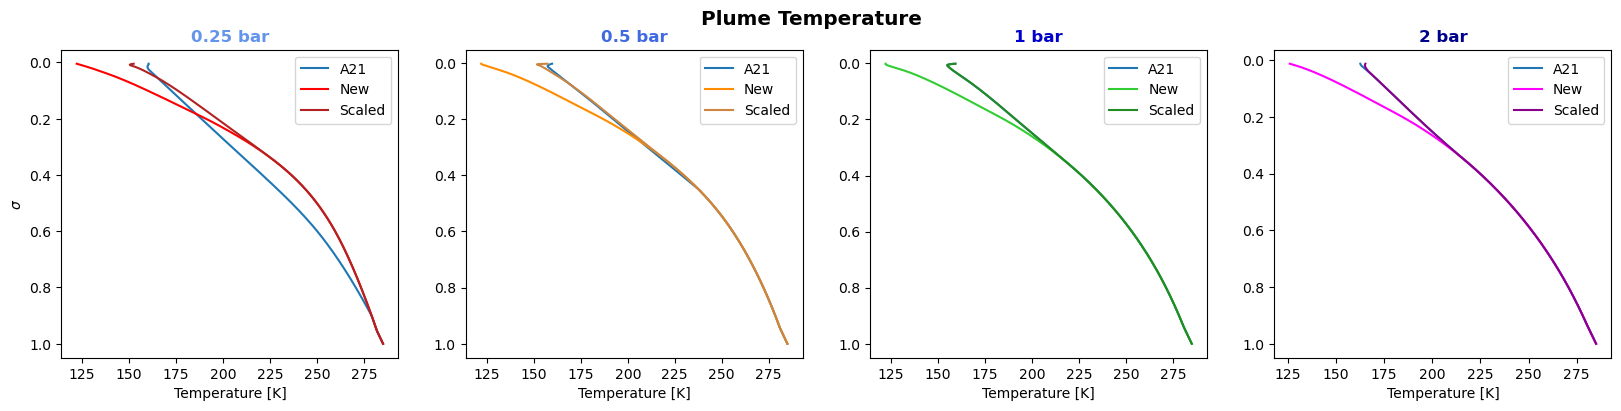

In [ ]:
## Plume temperature

plumetemp_fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(20, 4))
plumetemp_fig.suptitle('Plume Temperature', fontsize='x-large', weight='bold')
ax1.plot(p25agly_plume_temp.data, p25agly_pt_p, label='A21')
ax1.plot(p25new_plume_temp.data, p25new_pt_p, color='red', label='New')
ax1.plot(p25scaled_plume_temp.data, p25scaled_pt_p, color='firebrick', label='Scaled')
ax1.invert_yaxis()
ax1.legend()
ax1.set_xlabel('Temperature [K]')
ax1.set_ylabel(r'$\sigma$')
ax1.set_title('0.25 bar', color='cornflowerblue', weight='bold')

ax2.plot(p5agly_plume_temp.data, p5agly_pt_p, label='A21')
ax2.plot(p5new_plume_temp.data, p5new_pt_p, color='darkorange', label='New')
ax2.plot(p5scaled_plume_temp.data, p5scaled_pt_p, color='peru', label='Scaled')
ax2.invert_yaxis()
ax2.legend()
ax2.set_xlabel('Temperature [K]')
ax2.set_title('0.5 bar', color='royalblue', weight='bold')

ax3.plot(oneagly_plume_temp.data, oneagly_pt_p, label='A21')
ax3.plot(onenew_plume_temp.data, onenew_pt_p, color='limegreen', label='New')
ax3.plot(onescaled_plume_temp.data, onescaled_pt_p, color='forestgreen', label='Scaled')
ax3.invert_yaxis()
ax3.legend()
ax3.set_xlabel('Temperature [K]')
ax3.set_title('1 bar', color='mediumblue', weight='bold')

ax4.plot(twoagly_plume_temp.data, twoagly_pt_p, label='A21')
ax4.plot(twonew_plume_temp.data, twonew_pt_p, color='magenta', label='New')
ax4.plot(twoscaled_plume_temp.data, twoscaled_pt_p, color='darkmagenta', label='Scaled')
ax4.invert_yaxis()
ax4.legend()
ax4.set_xlabel('Temperature [K]')
ax4.set_title('2 bar', color='darkblue', weight='bold')

plumetemp_fig.savefig('/data/cluster4/jj22956/model_comparison_figures/combo plots/plume_temperature.pdf',
    bbox_inches="tight",
    pad_inches=0
)


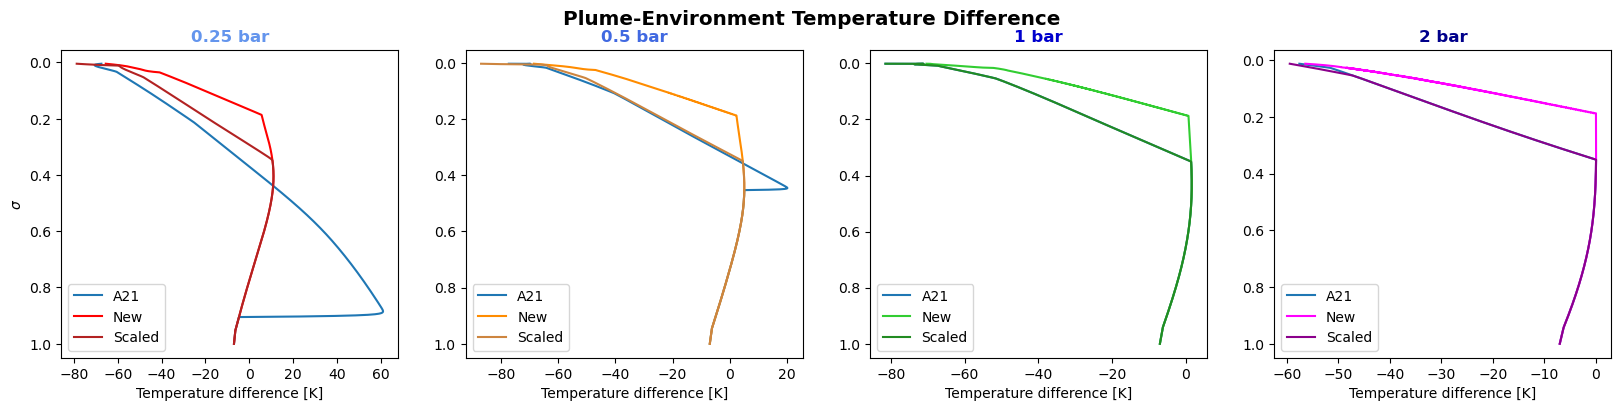

In [ ]:
## Plume-environment temperaature difference

envtemp_fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(20, 4))
envtemp_fig.suptitle('Plume-Environment Temperature Difference', fontsize='x-large', weight='bold')
ax1.plot(p25agly_env_temp.data, p25agly_et_p, label='A21')
ax1.plot(p25new_env_temp.data, p25new_et_p, color='red', label='New')
ax1.plot(p25scaled_env_temp.data, p25scaled_et_p, color='firebrick', label='Scaled')
ax1.invert_yaxis()
ax1.legend(loc='lower left')
ax1.set_xlabel('Temperature difference [K]')
ax1.set_ylabel(r'$\sigma$')
ax1.set_title('0.25 bar', color='cornflowerblue', weight='bold')

ax2.plot(p5agly_env_temp.data, p5agly_et_p, label='A21')
ax2.plot(p5new_env_temp.data, p5new_et_p, color='darkorange', label='New')
ax2.plot(p5scaled_env_temp.data, p5scaled_et_p, color='peru', label='Scaled')
ax2.invert_yaxis()
ax2.legend()
ax2.set_xlabel('Temperature difference [K]')
ax2.set_title('0.5 bar', color='royalblue', weight='bold')

ax3.plot(oneagly_env_temp.data, oneagly_et_p, label='A21')
ax3.plot(onenew_env_temp.data, onenew_et_p, color='limegreen', label='New')
ax3.plot(onescaled_env_temp.data, onescaled_et_p, color='forestgreen', label='Scaled')
ax3.invert_yaxis()
ax3.legend()
ax3.set_xlabel('Temperature difference [K]')
ax3.set_title('1 bar', color='mediumblue', weight='bold')

ax4.plot(twoagly_env_temp.data, twoagly_et_p, label='A21')
ax4.plot(twonew_env_temp.data, twonew_et_p, color='magenta', label='New')
ax4.plot(twoscaled_env_temp.data, twoscaled_et_p, color='darkmagenta', label='Scaled')
ax4.invert_yaxis()
ax4.legend()
ax4.set_xlabel('Temperature difference [K]')
ax4.set_title('2 bar', color='darkblue', weight='bold')

envtemp_fig.savefig('/data/cluster4/jj22956/model_comparison_figures/combo plots/plume_env_temp_diff.pdf',
    bbox_inches="tight",
    pad_inches=0
)


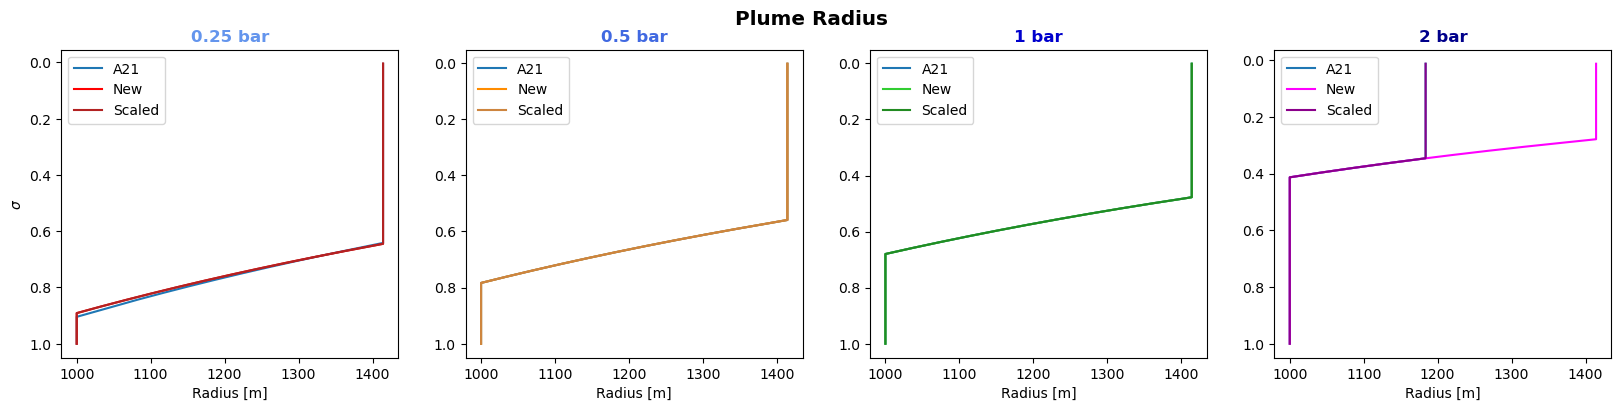

In [ ]:
## Plume radius

radius_fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(20, 4))
radius_fig.suptitle('Plume Radius', fontsize='x-large', weight='bold')

ax1.plot(p25agly_radius.data, p25agly_r_p, label='A21')
ax1.plot(p25new_radius.data, p25new_r_p, color='red', label='New')
ax1.plot(p25scaled_radius.data, p25scaled_r_p, color='firebrick', label='Scaled')
ax1.invert_yaxis()
ax1.legend()
ax1.set_xlabel('Radius [m]')
ax1.set_ylabel(r'$\sigma$')
ax1.set_title('0.25 bar', color='cornflowerblue', weight='bold')

ax2.plot(p5agly_radius.data, p5agly_r_p, label='A21')
ax2.plot(p5new_radius.data, p5new_r_p, color='darkorange', label='New')
ax2.plot(p5scaled_radius.data, p5scaled_r_p, color='peru', label='Scaled')
ax2.invert_yaxis()
ax2.legend()
ax2.set_xlabel('Radius [m]')
ax2.set_title('0.5 bar', color='royalblue', weight='bold')

ax3.plot(oneagly_radius.data, oneagly_r_p, label='A21')
ax3.plot(onenew_radius.data, onenew_r_p, color='limegreen', label='New')
ax3.plot(onescaled_radius.data, onescaled_r_p, color='forestgreen', label='Scaled')
ax3.invert_yaxis()
ax3.legend()
ax3.set_xlabel('Radius [m]')
ax3.set_title('1 bar', color='mediumblue', weight='bold')

ax4.plot(twoagly_radius.data, twoagly_r_p, label='A21')
ax4.plot(twonew_radius.data, twonew_r_p, color='magenta', label='New')
ax4.plot(twoscaled_radius.data, twoscaled_r_p, color='darkmagenta', label='Scaled')
ax4.invert_yaxis()
ax4.legend()
ax4.set_xlabel('Radius [m]')
ax4.set_title('2 bar', color='darkblue', weight='bold')

radius_fig.savefig('/data/cluster4/jj22956/model_comparison_figures/combo plots/plume_radius.pdf',
    bbox_inches="tight",
    pad_inches=0
)

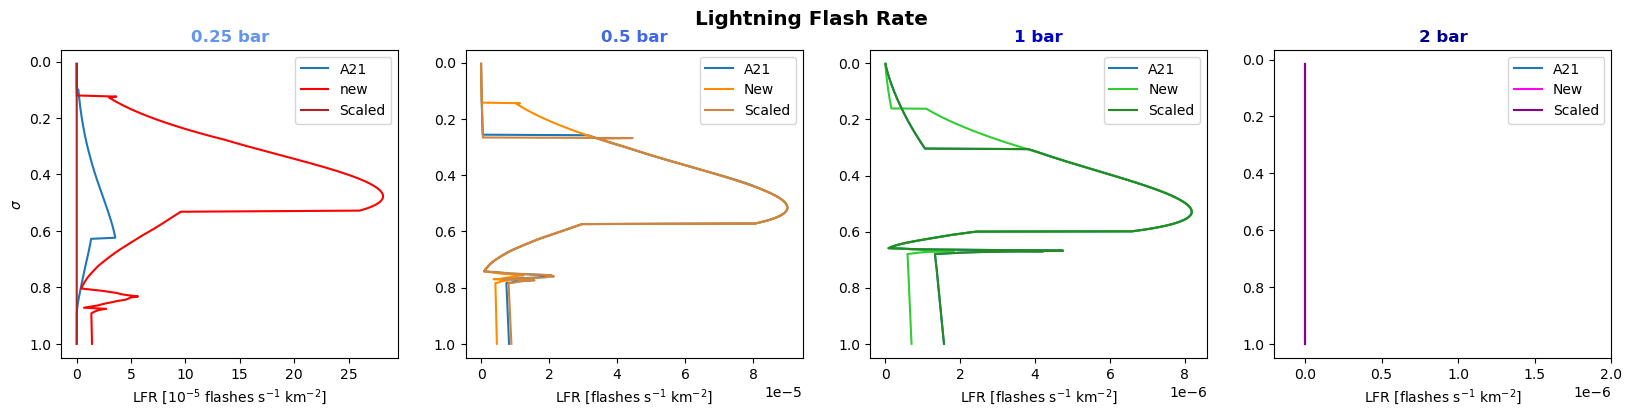

In [ ]:
## Lightning flash rate (LFR)

LFR_fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(20, 4))
LFR_fig.suptitle('Lightning Flash Rate', fontsize='x-large', weight='bold')

ax1.plot(p25agly_LFR.data, p25agly_LFR_p, label='A21')
ax1.plot(p25new_LFR.data, p25new_LFR_p, color='red', label='new')
ax1.plot(p25scaled_LFR.data/1e5, p25scaled_LFR_p, color='firebrick', label='Scaled')
ax1.invert_yaxis()
ax1.legend()
ax1.set_xticks([0, 5e-5, 10e-5, 15e-5, 20e-5, 25e-5], ['0', '5', '10', '15', '20', '25'])
ax1.set_xlabel(r'LFR [$10^{-5}$ flashes s$^{-1}$ km$^{-2}$]')
ax1.set_ylabel(r'$\sigma$')
ax1.set_title('0.25 bar', color='cornflowerblue', weight='bold')

ax2.plot(p5agly_LFR.data, p5agly_LFR_p, label='A21')
ax2.plot(p5new_LFR.data, p5new_LFR_p, color='darkorange', label='New')
ax2.plot(p5scaled_LFR.data, p5scaled_LFR_p, color='peru', label='Scaled')
ax2.invert_yaxis()
ax2.legend()
ax2.set_xlabel(r'LFR [flashes s$^{-1}$ km$^{-2}$]')
ax2.set_title('0.5 bar', color='royalblue', weight='bold')

ax3.plot(oneagly_LFR.data, oneagly_LFR_p, label='A21')
ax3.plot(onenew_LFR.data, onenew_LFR_p, color='limegreen', label='New')
ax3.plot(onescaled_LFR.data, onescaled_LFR_p, color='forestgreen', label='Scaled')
ax3.invert_yaxis()
ax3.legend()
ax3.set_xlabel(r'LFR [flashes s$^{-1}$ km$^{-2}$]')
ax3.set_title('1 bar', color='mediumblue', weight='bold')

ax4.plot(twoagly_LFR.data, twoagly_LFR_p, label='A21')
ax4.plot(twonew_LFR.data, twonew_LFR_p, color='magenta', label='New')
ax4.plot(twoscaled_LFR.data, twoscaled_LFR_p, color='darkmagenta', label='Scaled')
ax4.invert_yaxis()
ax4.legend()
ax4.set_xlim(-2e-7, 2e-6)
ax4.set_xlabel(r'LFR [flashes s$^{-1}$ km$^{-2}$]')
ax4.set_title('2 bar', color='darkblue', weight='bold')

LFR_fig.savefig('/data/cluster4/jj22956/model_comparison_figures/combo plots/LFR.pdf',
    bbox_inches="tight",
    pad_inches=0
)

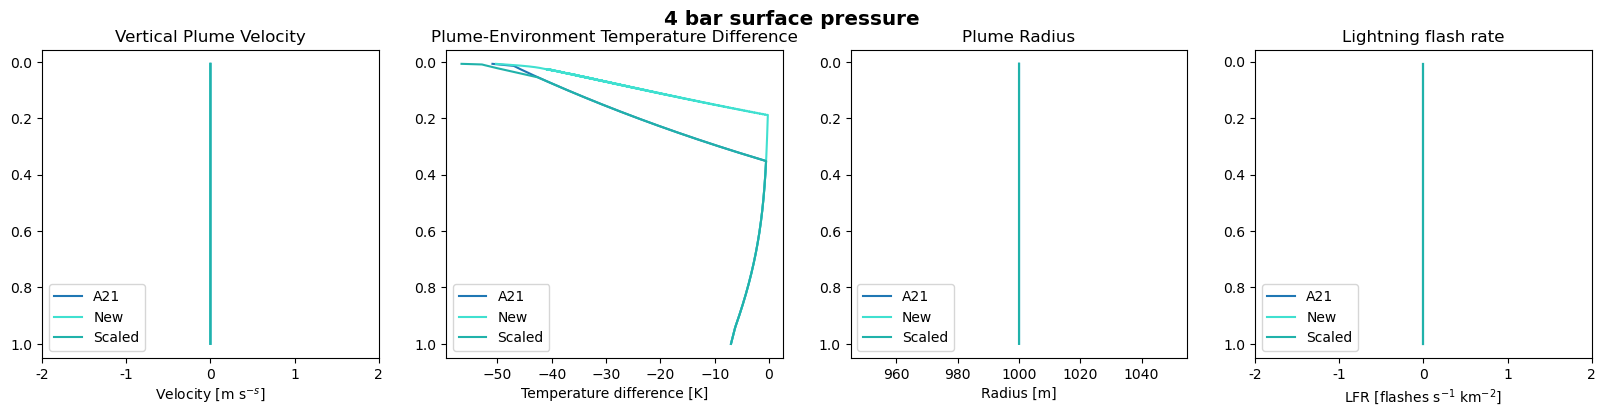

In [ ]:
## The 4 bar surface temp fig isn't a useful comparison because of its zero-results hence it's her on it's own

fourbar_fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(20, 4))
fourbar_fig.suptitle('4 bar surface pressure', fontsize='x-large', weight='bold')

ax1.plot(fouragly_velocity.data, fouragly_v_p, label='A21')
ax1.plot(fournew_velocity.data, fournew_v_p, color='turquoise', label='New')
ax1.plot(fourscaled_velocity.data, fourscaled_v_p, color='lightseagreen', label='Scaled')
ax1.invert_yaxis()
ax1.legend(loc='lower left')
ax1.set_xticks([-2, -1, 0, 1, 2], ['-2', '-1', '0', '1', '2'])
ax1.set_xlabel(r'Velocity [m s$^{-s}$]')
ax1.set_title('Vertical Plume Velocity')

ax2.plot(fouragly_env_temp.data, fouragly_et_p, label='A21')
ax2.plot(fournew_env_temp.data, fournew_et_p, color='turquoise', label='New')
ax2.plot(fourscaled_env_temp.data, fourscaled_et_p, color='lightseagreen', label='Scaled')
ax2.invert_yaxis()
ax2.legend(loc='lower left')
ax2.set_xlabel('Temperature difference [K]')
ax2.set_title('Plume-Environment Temperature Difference')

ax3.plot(fouragly_radius.data, fouragly_r_p, label='A21')
ax3.plot(fournew_radius.data, fournew_r_p, color='turquoise', label='New')
ax3.plot(fourscaled_radius.data, fourscaled_r_p, color='lightseagreen', label='Scaled')
ax3.invert_yaxis()
ax3.legend(loc='lower left')
ax3.set_xlabel('Radius [m]')
ax3.set_title('Plume Radius')

ax4.plot(fouragly_LFR.data, fouragly_LFR_p, label='A21')
ax4.plot(fournew_LFR.data, fournew_LFR_p, color='turquoise', label='New')
ax4.plot(fourscaled_LFR.data, fourscaled_LFR_p, color='lightseagreen', label='Scaled')
ax4.invert_yaxis()
ax4.legend(loc='lower left')
ax4.set_xticks([-2, -1, 0, 1, 2], ['-2', '-1', '0', '1', '2'])
ax4.set_xlabel(r'LFR [flashes s$^{-1}$ km$^{-2}$]')
ax4.set_title('Lightning flash rate')

fourbar_fig.savefig('/data/cluster4/jj22956/model_comparison_figures/combo plots/fourbar.pdf',
    bbox_inches="tight",
    pad_inches=0
)

In [20]:
## Finding max values of plume velocity and LFR from each plot

def maxvelocity(velocities):
    return max(velocities.data)

def maxLFR(LFRs):
    return max(LFRs.data)

In [21]:
## 0.25 bar surface pressure
max_p25_agly_velocity = maxvelocity(p25agly_velocity)
max_p25_scaled_velocity = maxvelocity(p25scaled_velocity)
max_p25_new_velocity = maxvelocity(p25new_velocity)
print('---------------')
print('0.25 surface pressure')
print('A21 vmax =', max_p25_agly_velocity)
print('sigma-scaled vmax =', max_p25_scaled_velocity)
print('New vmax =', max_p25_new_velocity)

## 0.5 bar surface pressure
max_p5_agly_velocity = maxvelocity(p5agly_velocity)
max_p5_scaled_velocity = maxvelocity(p5scaled_velocity)
max_p5_new_velocity = maxvelocity(p5new_velocity)
print('---------------')
print('0.5 surface pressure:')
print('A21 vmax =', max_p5_agly_velocity)
print('sigma-scaled vmax =', max_p5_scaled_velocity)
print('New vmax =', max_p5_new_velocity)

## 1 bar surface pressure
max_one_agly_velocity = maxvelocity(oneagly_velocity)
max_one_scaled_velocity = maxvelocity(onescaled_velocity)
max_one_new_velocity = maxvelocity(onenew_velocity)
print('---------------')
print('1 bar surface pressure:')
print('A21 vmax =', max_one_agly_velocity)
print('sigma-scaled vmax =', max_one_scaled_velocity)
print('New vmax =', max_one_new_velocity)

## 2 bar surface pressure
max_two_agly_velocity = maxvelocity(twoagly_velocity)
max_two_scaled_velocity = maxvelocity(twoscaled_velocity)
max_two_new_velocity = maxvelocity(twonew_velocity)
print('---------------')
print('2 bar surface pressure')
print('A21 vmax =', max_two_agly_velocity)
print('sigma-scaled vmax =', max_two_scaled_velocity)
print('New vmax =', max_two_new_velocity)

---------------
0.25 surface pressure
A21 vmax = 817.2374698837622
sigma-scaled vmax = 43.89654151180815
New vmax = 46.254088594677846
---------------
0.5 surface pressure:
A21 vmax = 40.57411250518959
sigma-scaled vmax = 29.64332660525373
New vmax = 30.925782009917604
---------------
1 bar surface pressure:
A21 vmax = 16.36258926983753
sigma-scaled vmax = 16.36258926983753
New vmax = 17.469686724709145
---------------
2 bar surface pressure
A21 vmax = 1.5809265708105333
sigma-scaled vmax = 1.5809265708105333
New vmax = 2.8613900211674617


In [22]:
## 0.25 bar surface pressure
max_p25_agly_LFR = maxLFR(p25agly_LFR)
max_p25_scaled_LFR = maxLFR(p25scaled_LFR)
max_p25_new_LFR = maxLFR(p25new_LFR)
print('---------------')
print('0.25 surface pressure')
print('A21 max LFR =', max_p25_agly_LFR)
print('sigma-scaled max LFR =', max_p25_scaled_LFR)
print('New max LFR =', max_p25_new_LFR)

## 0.5 bar surface pressure
max_p5_agly_LFR = maxLFR(p5agly_LFR)
max_p5_scaled_LFR = maxLFR(p5scaled_LFR)
max_p5_new_LFR = maxLFR(p5new_LFR)
print('---------------')
print('0.5 surface pressure:')
print('A21 max LFR =', max_p5_agly_LFR)
print('sigma-scaled max LFR =', max_p5_scaled_LFR)
print('New max LFR =', max_p5_new_LFR)

## 1 bar surface pressure
max_one_agly_LFR = maxLFR(oneagly_LFR)
max_one_scaled_LFR = maxLFR(onescaled_LFR)
max_one_new_LFR = maxLFR(onenew_LFR)
print('---------------')
print('1 bar surface pressure:')
print('A21 max LFR =', max_one_agly_LFR)
print('sigma-scaled max LFR =', max_one_scaled_LFR)
print('New max LFR =', max_one_new_LFR)

## 2 bar surface pressure
max_two_agly_LFR = maxLFR(twoagly_LFR)
max_two_scaled_LFR = maxLFR(twoscaled_LFR)
max_two_new_LFR = maxLFR(twonew_LFR)
print('---------------')
print('2 bar surface pressure')
print('A21 max LFR =', max_two_agly_LFR)
print('sigma-scaled max LFR =', max_two_scaled_LFR)
print('New max LFR =', max_two_new_LFR)

---------------
0.25 surface pressure
A21 max LFR = 3.5482597155207725e-05
sigma-scaled max LFR = 0.00028173450095511475
New max LFR = 0.00028173450095511475
---------------
0.5 surface pressure:
A21 max LFR = 8.99995531880366e-05
sigma-scaled max LFR = 8.99995531880366e-05
New max LFR = 8.99995531880366e-05
---------------
1 bar surface pressure:
A21 max LFR = 8.184295228343611e-06
sigma-scaled max LFR = 8.184295228343611e-06
New max LFR = 8.184295228343611e-06
---------------
2 bar surface pressure
A21 max LFR = 0.0
sigma-scaled max LFR = 0.0
New max LFR = 0.0


In [23]:
xvalues = [0.25, 0.5, 1, 2]
xvalues_no0p25 = [0.5, 1, 2]
## Aglyamov - disregarding the 0.25 bar pressure vmax
agly_vmaxes = [max_p25_agly_velocity, max_p5_agly_velocity, max_one_agly_velocity, max_two_agly_velocity]
agly_vmaxes_no0p25 = [max_p5_agly_velocity, max_one_agly_velocity, max_two_agly_velocity]
agly_LFRs = [max_p25_agly_LFR, max_p5_agly_LFR, max_one_agly_LFR, max_two_agly_LFR]

## Scaled
scaled_vmaxes = [max_p25_scaled_velocity, max_p5_scaled_velocity, max_one_scaled_velocity, max_two_scaled_velocity]
scaled_LFRs = [max_p25_scaled_LFR, max_p5_scaled_LFR, max_one_scaled_LFR, max_two_scaled_LFR]

## New
new_vmaxes = [max_p25_new_velocity, max_p5_new_velocity, max_one_new_velocity, max_two_new_velocity]
new_LFRs = [max_p25_new_LFR, max_p5_new_LFR, max_one_new_LFR, max_two_new_LFR]

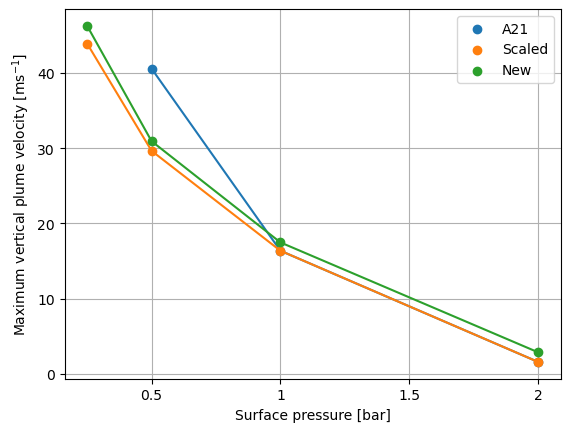

In [ ]:
## Comparing the maximum predicted plume velocity for each surface pressure plume between simulations
## Ignoring original model prediction for 0.25 bar surface pressure (anomaly)

plt.scatter(xvalues_no0p25, agly_vmaxes_no0p25, zorder=3, label='A21')
plt.plot(xvalues_no0p25, agly_vmaxes_no0p25, zorder=3)

plt.scatter(xvalues, scaled_vmaxes, zorder=3, label='Scaled')
plt.plot(xvalues, scaled_vmaxes, zorder=3)

plt.scatter(xvalues, new_vmaxes, zorder=3, label='New')
plt.plot(xvalues, new_vmaxes, zorder=3)

plt.xticks([0.5, 1, 1.5, 2], ['0.5', '1', '1.5', '2'])
plt.ylabel(r'Maximum vertical plume velocity [ms$^{-1}$]')
plt.xlabel('Surface pressure [bar]')
plt.grid()
plt.legend()
plt.savefig('/data/cluster4/jj22956/model_comparison_figures/max_vals/Vmax.pdf')
plt.show()

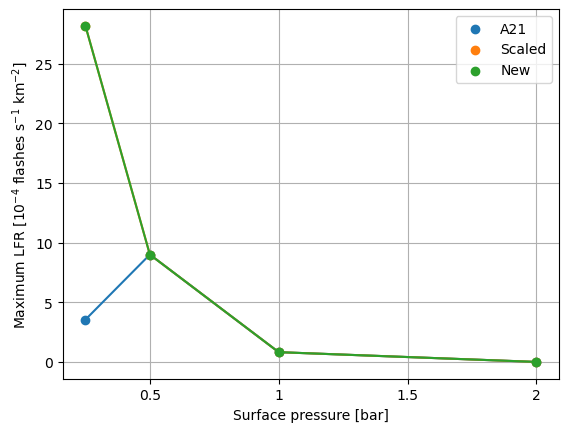

In [ ]:
## Comparing the maximum predicted LFR for each surface pressure plume between simulations

plt.scatter(xvalues, agly_LFRs, zorder=3, label='A21')
plt.plot(xvalues, agly_LFRs, zorder=3)

plt.scatter(xvalues, scaled_LFRs, zorder=3, label='Scaled')
plt.plot(xvalues, scaled_LFRs, zorder=3)

plt.scatter(xvalues, new_LFRs, zorder=3, label='New')
plt.plot(xvalues, new_LFRs, zorder=3)

plt.xticks([0.5, 1, 1.5, 2], ['0.5', '1', '1.5', '2'])
plt.yticks([0.0000, 0.00005, 0.00010, 0.00015, 0.00020, 0.00025], ['0', '5', '10', '15', '20', '25'])
plt.ylabel(r'Maximum LFR [10$^{-4}$ flashes s$^{-1}$ km$^{-2}$]')
plt.xlabel('Surface pressure [bar]')
plt.grid()
plt.legend()
plt.savefig('/data/cluster4/jj22956/model_comparison_figures/max_vals/LFRmax.pdf')
plt.show()

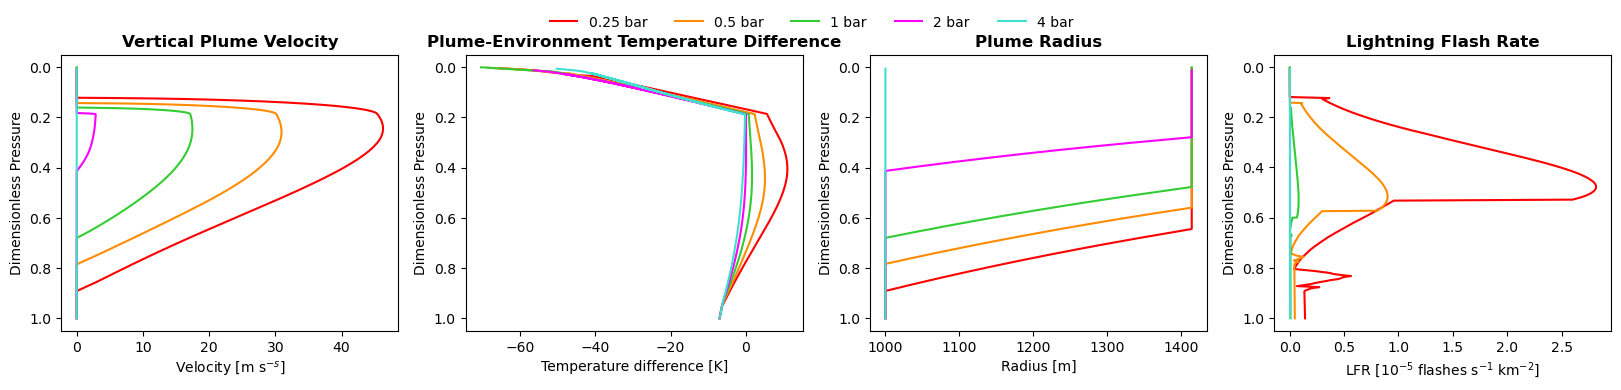

In [ ]:
## Creating a plot that is just for the data from the completely updated stratopsheric temperature function

newsim_fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(20, 4))
newsim_fig.suptitle('', fontsize='x-large', weight='bold')

ax1.plot(p25new_velocity.data, p25new_v_p, color='red', label='0.25 bar')
ax1.plot(p5new_velocity.data, p5new_v_p, color='darkorange', label='0.5 bar')
ax1.plot(onenew_velocity.data, onenew_v_p, color='limegreen', label='1 bar')
ax1.plot(twonew_velocity.data, twonew_v_p, color='magenta', label='2 bar')
ax1.plot(fournew_velocity.data, fournew_v_p, color='turquoise', label='4 bar')
ax1.invert_yaxis()
ax1.set_ylabel('Dimensionless Pressure')
# ax1.legend(loc='lower left')
# ax1.set_xticks([-2, -1, 0, 1, 2], ['-2', '-1', '0', '1', '2'])
ax1.set_xlabel(r'Velocity [m s$^{-s}$]')
ax1.set_title('Vertical Plume Velocity', weight='bold')

ax2.plot(p25new_env_temp.data, p25new_et_p, color='red')
ax2.plot(p5new_env_temp.data, p5new_et_p, color='darkorange')
ax2.plot(onenew_env_temp.data, onenew_et_p, color='limegreen')
ax2.plot(twonew_env_temp.data, twonew_et_p, color='magenta')
ax2.plot(fournew_env_temp.data, fournew_et_p, color='turquoise')
ax2.invert_yaxis()
ax2.set_ylabel('Dimensionless Pressure')
# ax2.legend(loc='lower left')
ax2.set_xlabel('Temperature difference [K]')
ax2.set_title('Plume-Environment Temperature Difference', weight='bold')

ax3.plot(p25new_radius.data, p25new_r_p, color='red')
ax3.plot(p5new_radius.data, p5new_r_p, color='darkorange')
ax3.plot(onenew_radius.data, onenew_r_p, color='limegreen')
ax3.plot(twonew_radius.data, twonew_r_p, color='magenta')
ax3.plot(fournew_radius.data, fournew_r_p, color='turquoise')
ax3.invert_yaxis()
ax3.set_ylabel('Dimensionless Pressure')
# ax3.legend(loc='lower left')
ax3.set_xlabel('Radius [m]')
ax3.set_title('Plume Radius', weight='bold')

ax4.plot(p25new_LFR.data, p25new_LFR_p, color='red')
ax4.plot(p5new_LFR.data, p5new_LFR_p, color='darkorange')
ax4.plot(onenew_LFR.data, onenew_LFR_p, color='limegreen')
ax4.plot(twonew_LFR.data, twonew_LFR_p, color='magenta')
ax4.plot(fournew_LFR.data, fournew_LFR_p, color='turquoise')
ax4.invert_yaxis()
ax4.set_ylabel('Dimensionless Pressure')
# ax4.legend(loc='lower left')
ax4.set_xticks([0, 5e-5, 10e-5, 15e-5, 20e-5, 25e-5], ['0.0', '0.5', '1.0', '1.5', '2.0', '2.5'])
ax4.set_xlabel(r'LFR [10$^{-5}$ flashes s$^{-1}$ km$^{-2}$]')
ax4.set_title('Lightning Flash Rate', weight='bold')


newsim_fig.legend(
    ncols=5,
    loc='upper center',
    bbox_to_anchor=(0.5, 0.93),
    frameon=False
)

newsim_fig.subplots_adjust(top=0.8)


newsim_fig.savefig(
    '/data/cluster4/jj22956/model_comparison_figures/combo plots/NewSim.png',
    bbox_inches="tight",
    pad_inches=0
)

newsim_fig.savefig(
    '/data/cluster4/jj22956/model_comparison_figures/combo plots/NewSim.pdf',
    bbox_inches="tight",
    pad_inches=0
)

In [ ]:
## Now, trying to calculate the global LFR for 1 bar surface pressure
## Done by extrapolating the vertically integrated LFR from this case

In [27]:
# p25flashes = p25agly_LFR.collapsed('air_pressure', iris.analysis.SUM)
p25flashes = np.array(p25agly_LFR.data)
p25sum = np.sum(p25flashes)
p25sum

np.float64(0.0025175748024689895)

In [28]:
## Calculation of the surface area of the region of the dayside where lightning activity is possible
def lightning_surface_area(R):
    planet_surface_area = 4 * np.pi * R**2
    planet_dayside = planet_surface_area / 2
    # Based on global surface temperature distributions, we approximate that 1/4 of the dayside is warm enough for lightning generation
    substellar_region = planet_dayside / 4   
    return substellar_region

In [29]:
Earth_radius = 6371 # [km]
TRAPPIST1e_radius = 0.910 * Earth_radius
TRAPPIST_lightning_region = lightning_surface_area(TRAPPIST1e_radius) # [km-2]

In [30]:
def zonedlightningflashes(cube):
    flashes = cube.collapsed('air_pressure', iris.analysis.SUM)
    flashes_per_second = flashes.data * TRAPPIST_lightning_region
    return flashes_per_second

In [31]:
zonedlightningflashes(p25new_LFR)

np.float64(1142175.792723136)

In [32]:
## 0.25 bar surface pressure
p25_agly_flashes = zonedlightningflashes(p25agly_LFR)
p25_scaled_flashes = zonedlightningflashes(p25scaled_LFR)
p25_new_flashes = zonedlightningflashes(p25new_LFR)


## 0.5 bar surface pressure
p5_agly_flashes = zonedlightningflashes(p5agly_LFR)
p5_scaled_flashes = zonedlightningflashes(p5scaled_LFR)
p5_new_flashes = zonedlightningflashes(p5new_LFR)


## 1 bar surface pressure
one_agly_flashes = zonedlightningflashes(oneagly_LFR)
one_scaled_flashes = zonedlightningflashes(onescaled_LFR)
one_new_flashes = zonedlightningflashes(onenew_LFR)


## 2 bar surface pressure
two_agly_flashes = zonedlightningflashes(twoagly_LFR)
two_scaled_flashes = zonedlightningflashes(twoscaled_LFR)
two_new_flashes = zonedlightningflashes(twonew_LFR)


In [33]:
xvalues = [0.25, 0.5, 1, 2]
xvalues_no0p25 = [0.5, 1, 2]
## Aglyamov - disregarding the 0.25 bar pressure vmax
all_agly_flashes = [p25_agly_flashes, p5_agly_flashes, one_agly_flashes, two_agly_flashes]
all_agly_flashes_no0p25 = [p5_agly_flashes, one_agly_flashes, two_agly_flashes]

## Scaled
all_scaled_flashes = [p25_scaled_flashes, p5_scaled_flashes, one_scaled_flashes, two_scaled_flashes]

## New
all_new_flashes = [p25_new_flashes, p5_new_flashes, one_new_flashes, two_new_flashes]

In [34]:
agly_flashes_array = np.array(all_agly_flashes)
new_flashes_array = np.array(all_new_flashes)
scaled_flashes_array = np.array(all_scaled_flashes)

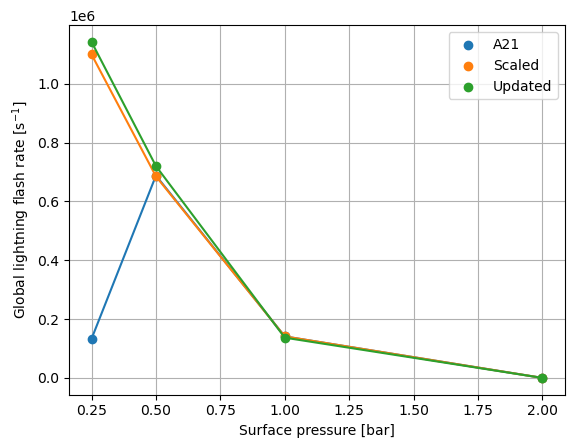

In [ ]:
## Comparing the maximum predicted LFR for each surface pressure plume between simulations

plt.scatter(xvalues, agly_flashes_array, zorder=3, label='A21')
plt.plot(xvalues, agly_flashes_array, zorder=3)

plt.scatter(xvalues, scaled_flashes_array, zorder=3, label='Scaled')
plt.plot(xvalues, scaled_flashes_array, zorder=3)

plt.scatter(xvalues, new_flashes_array, zorder=3, label='Updated')
plt.plot(xvalues, new_flashes_array, zorder=3)

# plt.xticks([0.5, 1, 1.5, 2], ['0.5', '1', '1.5', '2'])
# plt.yticks([0.0000, 0.00005, 0.00010, 0.00015, 0.00020, 0.00025], ['0', '5', '10', '15', '20', '25'])
plt.ylabel(r'Global lightning flash rate [s$^{-1}$]')
plt.xlabel('Surface pressure [bar]')
plt.grid()
plt.legend()
plt.savefig('/data/cluster4/jj22956/model_comparison_figures/max_vals/totalflashes.pdf')
plt.show()

In [36]:
print(new_flashes_array/1e6)

[1.14217579 0.71997606 0.13679305 0.        ]


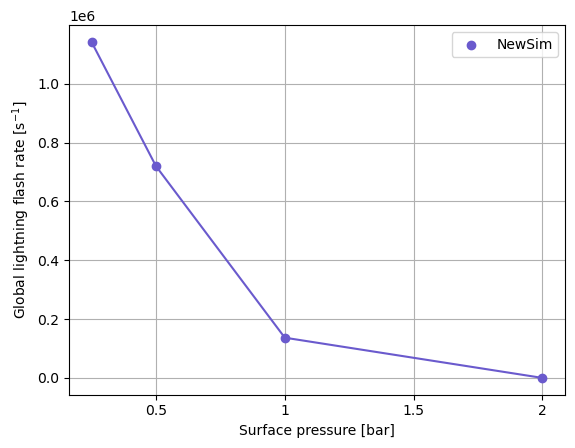

In [37]:
plt.scatter(xvalues, new_flashes_array, color='slateblue' , zorder=3, label='NewSim')
plt.plot(xvalues, new_flashes_array,  color='slateblue' , zorder=3)

plt.xticks([0.5, 1, 1.5, 2], ['0.5', '1', '1.5', '2'])
plt.ylabel(r'Global lightning flash rate [s$^{-1}$]')
plt.xlabel('Surface pressure [bar]')
plt.grid()
plt.legend()
plt.savefig('/data/cluster4/jj22956/model_comparison_figures/max_vals/NewSim_totalflashes.pdf')
plt.show()

In [38]:
## Global flash rates (overestimates by a lot)

print(agly_flashes_array)
print(new_flashes_array)
print(scaled_flashes_array)

[132923.03689715 687842.32451465 141083.88874146      0.        ]
[1142175.79272314  719976.06015136  136793.05415023       0.        ]
[1099578.46256641  685125.46542719  141083.88874146       0.        ]


In [ ]:
## Calculating the vertically integrated LFR (total number of lightning flashes)

In [39]:
def lightningflashes(cube):
    flashes = cube.collapsed('air_pressure', iris.analysis.SUM)
    flashes_per_second = flashes.data
    return flashes_per_second

In [40]:
## 0.25 bar surface pressure
p25_agly_totalLFR = lightningflashes(p25agly_LFR)
p25_scaled_totalLFR = lightningflashes(p25scaled_LFR)
p25_new_totalLFR = lightningflashes(p25new_LFR)


## 0.5 bar surface pressure
p5_agly_totalLFR = lightningflashes(p5agly_LFR)
p5_scaled_totalLFR = lightningflashes(p5scaled_LFR)
p5_new_totalLFR = lightningflashes(p5new_LFR)


## 1 bar surface pressure
one_agly_totalLFR = lightningflashes(oneagly_LFR)
one_scaled_totalLFR = lightningflashes(onescaled_LFR)
one_new_totalLFR = lightningflashes(onenew_LFR)


## 2 bar surface pressure
two_agly_totalLFR = lightningflashes(twoagly_LFR)
two_scaled_totalLFR = lightningflashes(twoscaled_LFR)
two_new_totalLFR = lightningflashes(twonew_LFR)

In [41]:
xvalues = [0.25, 0.5, 1, 2]
xvalues_no0p25 = [0.5, 1, 2]
## Aglyamov - disregarding the 0.25 bar pressure vmax
all_agly_tot_LFRs = [p25_agly_totalLFR, p5_agly_totalLFR, one_agly_totalLFR, two_agly_totalLFR]
all_agly_tot_LFRs_no0p25 = [p5_agly_totalLFR, one_agly_totalLFR, two_agly_totalLFR]

## Scaled
all_scaled_tot_LFRs = [p25_scaled_totalLFR, p5_scaled_totalLFR, one_scaled_totalLFR, two_scaled_totalLFR]

## New
all_new_tot_LFRs = [p25_new_totalLFR, p5_new_totalLFR, one_new_totalLFR, two_new_totalLFR]

In [42]:
print(all_agly_tot_LFRs)
print(all_agly_tot_LFRs_no0p25)
print(all_scaled_tot_LFRs)
print(all_new_tot_LFRs)

[array(0.00251757), array(0.0130278), array(0.00267214), array(0.)]
[array(0.0130278), array(0.00267214), array(0.)]
[array(0.02082612), array(0.01297634), array(0.00267214), array(0.)]
[array(0.02163292), array(0.01363641), array(0.00259087), array(0.)]


In [48]:
agly_tot_power_array = np.array(all_agly_tot_LFRs) * 1.5 * 10**9
all_agly_tot_power_nop05_array = np.array(all_agly_tot_LFRs_no0p25) * 1.5 * 10**9
scaled_tot_power_array = np.array(all_scaled_tot_LFRs) * 1.5 * 10**9
new_tot_power_array = np.array(all_new_tot_LFRs) * 1.5 * 10**9

In [50]:
print(agly_tot_power_array/1e6)
print(all_agly_tot_power_nop05_array/1e6)
print(new_tot_power_array/1e6)
print(scaled_tot_power_array/1e6)

[ 3.7763622  19.54169734  4.00821315  0.        ]
[19.54169734  4.00821315  0.        ]
[32.44937517 20.4546213   3.88630994  0.        ]
[31.23917902 19.46451099  4.00821315  0.        ]


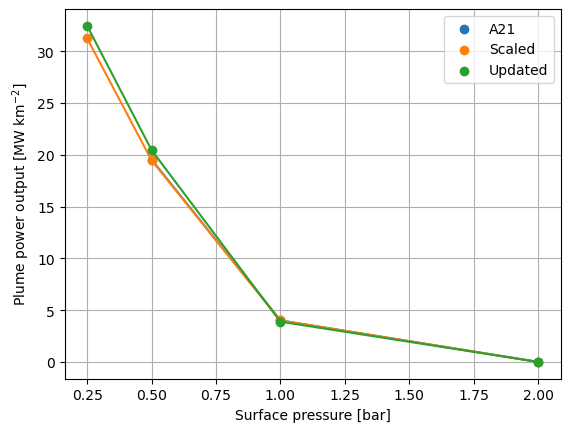

In [ ]:
## Comparing the power output for each surface pressure plume between simulations

plt.scatter(xvalues_no0p25, all_agly_tot_power_nop05_array/1e6, zorder=3, label='A21')
plt.plot(xvalues_no0p25, all_agly_tot_power_nop05_array/1e6, zorder=3)

plt.scatter(xvalues, scaled_tot_power_array/1e6, zorder=3, label='Scaled')
plt.plot(xvalues, scaled_tot_power_array/1e6, zorder=3)

plt.scatter(xvalues, new_tot_power_array/1e6, zorder=3, label='Updated')
plt.plot(xvalues, new_tot_power_array/1e6, zorder=3)

# plt.xticks([0.5, 1, 1.5, 2], ['0.5', '1', '1.5', '2'])
# plt.yticks([0.0000, 0.00005, 0.00010, 0.00015, 0.00020, 0.00025], ['0', '5', '10', '15', '20', '25'])
plt.ylabel(r'Plume power output [MW km$^{-2}$]')
plt.xlabel('Surface pressure [bar]')
plt.grid()
plt.legend()
plt.savefig('/data/cluster4/jj22956/model_comparison_figures/combo plots/lightningpower.pdf')
plt.show()

In [ ]:
print((new_tot_LFRs_array/1e6) - (scaled_tot_LFRs_array/1e6)) # units: MJ

[ 1.21019615  0.99011031 -0.12190322  0.        ]


In [ ]:
print((new_tot_LFRs_array/1e6) - (agly_tot_LFRs_array/1e6)) # units: MJ

[28.67301297  0.91292396 -0.12190322  0.        ]


In [ ]:
print(new_tot_power_array/1e6) # units: megaWatt

[32.44937517 20.4546213   3.88630994  0.        ]
